# TP : optimisation implémentée avec NumPy
Régression, classification et clustering sur huit jeux de données — sept méthodes (GD, GD-LS, SGD, Momentum, AdaGrad, RMSprop, Adam), NumPy.



In [1]:
import csv, json, os, glob, zipfile, time
from types import SimpleNamespace
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
print("numpy", np.__version__)

numpy 2.4.3


## 1. Noyau : optimiseurs, modèles, gradients, métriques

In [2]:
METHODS = ["GD", "GD-LS", "SGD", "Momentum", "AdaGrad", "RMSprop", "Adam"]
FULL = {"GD", "GD-LS"}                      # methodes a lot complet
MU = RHO = B1 = 0.9
B2 = 0.999
EPS = 1e-8


class Counter:
    def __init__(s): s.grad = s.loss = s.upd = s.hess = 0
    def dict(s): return dict(grad=s.grad, loss=s.loss, upd=s.upd, hess=s.hess)


# --------------------------------------------------------------------------
# Recherche lineaire (GD + recherche)
# --------------------------------------------------------------------------
def golden(f, a, b, it=8):
    r = (5 ** .5 - 1) / 2
    c, d = b - r * (b - a), a + r * (b - a)
    fc, fd = f(c), f(d)
    for _ in range(it):
        if fc < fd:
            b, d, fd = d, c, fc; c = b - r * (b - a); fc = f(c)
        else:
            a, c, fc = c, d, fd; d = a + r * (b - a); fd = f(d)
    return (a + b) / 2


def line_step(prob, th, g, cnt):
    """Quadratique : pas exact g'g / g'Hg.  Sinon : grille geometrique bornee
    eta_max*2^-k (12 evaluations) + raffinement par section doree (10 evaluations)."""
    if hasattr(prob, "H"):
        cnt.hess += 1
        den = float(g @ (prob.H @ g))
        return float((g @ g) / den) if den > 0 else float(prob.eta_max)

    def f(e):
        cnt.loss += 1
        v = prob.loss(th - float(e) * g)
        return v if np.isfinite(v) else np.inf
    etas = prob.eta_max * 0.5 ** np.arange(12)
    vals = [f(e) for e in etas]
    k = int(np.argmin(vals))
    lo = etas[k + 1] if k + 1 < len(etas) else 0.0
    hi = etas[k - 1] if k > 0 else etas[0]
    e2 = golden(f, lo, hi, 8)
    return float(e2) if f(e2) < vals[k] else float(etas[k])


# --------------------------------------------------------------------------
# Boucle d'optimisation commune aux sept methodes
# --------------------------------------------------------------------------
def run(prob, method, eta, epochs, batch, seed, patience=None):
    rng = np.random.default_rng(1000 + seed)          # melange des mini-lots
    th = prob.init(seed).copy()
    m = np.zeros_like(th); s = np.zeros_like(th); t = 0
    cnt = Counter(); n = prob.n_train; H = {}
    eta = None if eta is None else float(eta)

    def rec(ep, tt):                                  # suivi hors chronometre
        r = prob.monitor(th)
        H.setdefault("epoch", []).append(ep); H.setdefault("time", []).append(tt)
        for k, v in r.items(): H.setdefault(k, []).append(float(v))
        return r

    r = rec(0, 0.0)
    best = (r["val_crit"], th.copy(), 0); tt = 0.0; bad = 0; div = False
    for ep in range(1, epochs + 1):
        t0 = time.perf_counter()
        if method in FULL:
            batches = [None]
        else:
            p = rng.permutation(n); batches = [p[i:i + batch] for i in range(0, n, batch)]
        for idx in batches:
            g = prob.grad(th, idx); cnt.grad += 1; cnt.upd += 1; t += 1
            if method == "GD-LS": th = th - line_step(prob, th, g, cnt) * g
            elif method in ("GD", "SGD"): th = th - eta * g
            elif method == "Momentum": m = MU * m + g; th = th - eta * m
            elif method == "AdaGrad": s = s + g * g; th = th - eta * g / (np.sqrt(s) + EPS)
            elif method == "RMSprop":
                s = RHO * s + (1 - RHO) * g * g; th = th - eta * g / (np.sqrt(s) + EPS)
            elif method == "Adam":
                m = B1 * m + (1 - B1) * g; s = B2 * s + (1 - B2) * g * g
                th = th - eta * (m / (1 - B1 ** t)) / (np.sqrt(s / (1 - B2 ** t)) + EPS)
            else: raise ValueError(method)
        tt += time.perf_counter() - t0
        if not np.isfinite(th).all(): div = True; break
        r = rec(ep, tt)
        if r["val_crit"] < best[0]: best = (r["val_crit"], th.copy(), ep); bad = 0
        else: bad += 1
        if patience and bad >= patience: break
    return dict(method=method, eta=eta, seed=seed, theta=best[1], best_crit=float(best[0]),
                best_ep=best[2], time=tt, cnt=cnt.dict(), hist=H, diverged=div,
                epochs_run=len(H["epoch"]) - 1)


def gradcheck(prob, th, idx=None, k=8, h=1e-5, seed=0):
    """Erreur relative max, differences finies centrales, k coordonnees tirees au hasard."""
    g = prob.grad(th, idx); rng = np.random.default_rng(seed); errs = []
    for i in rng.choice(th.size, min(k, th.size), replace=False):
        e = np.zeros_like(th); e[i] = h
        gn = (prob.loss(th + e, idx) - prob.loss(th - e, idx)) / (2 * h)
        errs.append(abs(gn - g[i]) / max(abs(gn), abs(g[i]), 1e-12))
    return float(max(errs))


# --------------------------------------------------------------------------
# Exercice 1 : OLS / ridge / ridge a noyau RBF  (forme unifiee A theta ~ y)
# --------------------------------------------------------------------------
def rbf(A, B, sig):
    d2 = (A * A).sum(1)[:, None] + (B * B).sum(1)[None] - 2 * A @ B.T
    return np.exp(-np.maximum(d2, 0) / (2 * sig ** 2))


class RegProblem:
    """lineaire : A=[1,X], R=P=diag(0,1..1) ; noyau : A=K, R=K.
    J = ||A th - y||^2/(2n) + lam/2 th'R th ; grad = A'(A th - y)/n + lam R th ;
    H = A'A/n + lam R  (X'X/n+lam P  ou  K^2/n + lam K)."""
    def __init__(s, kind, A, Y, Av, Yv, At, Yt, R, lam, ymu, ysd, Xs=None, sig=None):
        s.kind, s.A, s.Y, s.Av, s.Yv, s.At, s.Yt, s.R, s.lam = kind, A, Y, Av, Yv, At, Yt, R, lam
        s.n_train = len(Y); s.ymu, s.ysd, s.Xs, s.sig = ymu, ysd, Xs, sig
        s.dim = A.shape[1]; s.eta_max = 1.0
        s.H = A.T @ A / s.n_train + lam * R
        ev = np.linalg.eigvalsh(s.H); s.L = float(ev[-1]) if ev[-1] > 0 else 1.0

    def init(s, seed): return 0.01 * np.random.default_rng(seed).standard_normal(s.dim)

    def loss(s, th, idx=None):
        A, Y = (s.A, s.Y) if idx is None else (s.A[idx], s.Y[idx])
        r = A @ th - Y
        return 0.5 * np.mean(r * r) + 0.5 * s.lam * th @ (s.R @ th)

    def grad(s, th, idx=None):
        A, Y = (s.A, s.Y) if idx is None else (s.A[idx], s.Y[idx])
        return A.T @ (A @ th - Y) / len(Y) + s.lam * (s.R @ th)

    def closed(s):                       # solution de controle (jamais utilisee comme entrainement)
        n = s.n_train
        if s.kind == "lin":
            return np.linalg.lstsq(s.H, s.A.T @ s.Y / n, rcond=None)[0]
        return np.linalg.solve(s.A + n * s.lam * np.eye(n), s.Y)

    def pred(s, th, split):
        A = dict(train=s.A, val=s.Av, test=s.At)[split]
        return (A @ th) * s.ysd + s.ymu

    def metrics(s, th, split):
        y = dict(train=s.Y, val=s.Yv, test=s.Yt)[split] * s.ysd + s.ymu
        e = s.pred(th, split) - y
        return dict(mse=float(np.mean(e ** 2)), rmse=float(np.sqrt(np.mean(e ** 2))),
                    mae=float(np.mean(np.abs(e))), r2=float(1 - (e ** 2).sum() / ((y - y.mean()) ** 2).sum()))

    def monitor(s, th):
        return dict(train_loss=s.loss(th), val_crit=s.metrics(th, "val")["rmse"])

    def predict_new(s, th, Xs):
        A = np.c_[np.ones(len(Xs)), Xs] if s.kind == "lin" else rbf(Xs, s.Xs, s.sig)
        return (A @ th) * s.ysd + s.ymu


# --------------------------------------------------------------------------
# Exercice 2 : perceptron a trois couches, tanh + softmax
# --------------------------------------------------------------------------
class MLP:
    def __init__(s, D, sizes, lam=1e-4, dtype=np.float64):
        s.Xtr, s.ytr, s.Xva, s.yva, s.Xte, s.yte = [D[k].astype(dtype) if k[0] == "X" else D[k]
                                                     for k in ("Xtr", "ytr", "Xva", "yva", "Xte", "yte")]
        s.sizes, s.lam, s.dtype = sizes, lam, dtype
        s.n_train = len(s.Xtr); s.eta_max = 2.0
        s.shapes = []
        for a, b in zip(sizes[:-1], sizes[1:]): s.shapes += [(a, b), (b,)]
        s.sl, o = [], 0
        for sh in s.shapes:
            k = int(np.prod(sh)); s.sl.append(slice(o, o + k)); o += k
        s.dim = o

    def init(s, seed):                    # Xavier (Glorot normal), biais nuls
        rng = np.random.default_rng(seed); th = np.zeros(s.dim, s.dtype)
        for i in range(0, len(s.shapes), 2):
            a, b = s.shapes[i]
            th[s.sl[i]] = (rng.standard_normal((a, b)) * np.sqrt(2 / (a + b))).ravel()
        return th

    def parts(s, th): return [th[sl].reshape(sh) for sl, sh in zip(s.sl, s.shapes)]

    def fwd(s, th, X):
        W1, b1, W2, b2, W3, b3 = s.parts(th)
        H1 = np.tanh(X @ W1 + b1); H2 = np.tanh(H1 @ W2 + b2)
        return H1, H2, H2 @ W3 + b3

    @staticmethod
    def lse(Z):
        m = Z.max(1, keepdims=True); return m + np.log(np.exp(Z - m).sum(1, keepdims=True))

    def reg(s, th): return 0.5 * s.lam * sum(float((W * W).sum()) for W in s.parts(th)[0::2])

    def loss(s, th, idx=None):
        X, y = (s.Xtr, s.ytr) if idx is None else (s.Xtr[idx], s.ytr[idx])
        Z = s.fwd(th, X)[2]
        return float((s.lse(Z)[:, 0] - Z[np.arange(len(y)), y]).mean()) + s.reg(th)

    def grad(s, th, idx=None):
        X, y = (s.Xtr, s.ytr) if idx is None else (s.Xtr[idx], s.ytr[idx])
        W1, b1, W2, b2, W3, b3 = s.parts(th)
        H1, H2, Z = s.fwd(th, X); B = len(y)
        D3 = np.exp(Z - s.lse(Z)); D3[np.arange(B), y] -= 1; D3 /= B         # (P - Y)/|B|
        D2 = (D3 @ W3.T) * (1 - H2 ** 2); D1 = (D2 @ W2.T) * (1 - H1 ** 2)
        g = np.empty_like(th); sl = s.sl
        g[sl[0]] = (X.T @ D1 + s.lam * W1).ravel(); g[sl[1]] = D1.sum(0)
        g[sl[2]] = (H1.T @ D2 + s.lam * W2).ravel(); g[sl[3]] = D2.sum(0)
        g[sl[4]] = (H2.T @ D3 + s.lam * W3).ravel(); g[sl[5]] = D3.sum(0)
        return g

    def probs(s, th, X, chunk=10000):
        out = []
        for i in range(0, len(X), chunk):
            Z = s.fwd(th, X[i:i + chunk])[2]; out.append(np.exp(Z - s.lse(Z)))
        return np.concatenate(out)

    def ce_acc(s, th, X, y):
        P = s.probs(th, X)
        return float(-np.log(np.maximum(P[np.arange(len(y)), y], 1e-300)).mean()), float((P.argmax(1) == y).mean())

    def monitor(s, th):
        ct, at = s.ce_acc(th, s.Xtr, s.ytr); cv, av = s.ce_acc(th, s.Xva, s.yva)
        return dict(train_loss=ct + s.reg(th), train_ce=ct, train_acc=at, val_loss=cv, val_acc=av, val_crit=cv)


def cls_metrics(P, y, C):
    pred = P.argmax(1); cm = np.zeros((C, C), int); np.add.at(cm, (y, pred), 1)
    tp = np.diag(cm).astype(float); pc, rc = cm.sum(0), cm.sum(1)
    prec = np.where(pc > 0, tp / np.maximum(pc, 1), np.nan)
    rec = np.where(rc > 0, tp / np.maximum(rc, 1), np.nan)
    den = 2 * tp + (pc - tp) + (rc - tp)
    f1 = np.where(den > 0, 2 * tp / np.maximum(den, 1), np.nan)
    ce = float(-np.log(np.maximum(P[np.arange(len(y)), y], 1e-300)).mean())
    return dict(acc=float((pred == y).mean()), prec=float(np.nanmean(prec)), rec=float(np.nanmean(rec)),
                f1=float(np.nanmean(f1)), ce=ce, cm=cm, f1c=f1, undef_prec=int(np.isnan(prec).sum()))


# --------------------------------------------------------------------------
# Exercice 3 : clustering par optimisation des centroides
# --------------------------------------------------------------------------
class Cluster:
    def __init__(s, Xtr, Xva, K, tau):
        s.Xtr, s.Xva, s.K, s.tau = Xtr, Xva, K, tau
        s.n_train = len(Xtr); s.eta_max = 1.0; s.dim = K * Xtr.shape[1]

    def init(s, seed):                    # K points distincts, memes graines pour toutes les methodes
        i = np.random.default_rng(seed).choice(s.n_train, s.K, replace=False)
        return s.Xtr[i].copy().ravel()

    @staticmethod
    def D(C, X):                          # ||x||^2 + ||c||^2 - 2 x.c  (pas de tableau n x K x d)
        return np.maximum((X * X).sum(1)[:, None] + (C * C).sum(1)[None] - 2 * X @ C.T, 0)

    def J(s, C, X):
        Z = -s.D(C, X) / s.tau; m = Z.max(1, keepdims=True)
        lse = m[:, 0] + np.log(np.exp(Z - m).sum(1))
        return float(-s.tau * np.mean(lse - np.log(s.K)))

    def loss(s, th, idx=None):
        X = s.Xtr if idx is None else s.Xtr[idx]
        return s.J(th.reshape(s.K, -1), X)

    def grad(s, th, idx=None):
        X = s.Xtr if idx is None else s.Xtr[idx]; C = th.reshape(s.K, -1); n = len(X)
        Z = -s.D(C, X) / s.tau; Z = Z - Z.max(1, keepdims=True)
        Q = np.exp(Z); Q /= Q.sum(1, keepdims=True)
        return (2.0 / n * (Q.sum(0)[:, None] * C - Q.T @ X)).ravel()

    def monitor(s, th):
        C = th.reshape(s.K, -1)
        return dict(train_loss=s.J(C, s.Xtr), val_crit=s.J(C, s.Xva),
                    inertia=float(s.D(C, s.Xva).min(1).mean()))


def lloyd(prob, seed, iters):
    """Reference distincte : algorithme de Lloyd (affectation dure) sur les memes donnees/graines."""
    C = prob.init(seed).reshape(prob.K, -1).copy(); H = {}; tt = 0.0; prev = None

    def rec(ep):
        r = prob.monitor(C.ravel()); H.setdefault("epoch", []).append(ep); H.setdefault("time", []).append(tt)
        for k, v in r.items(): H.setdefault(k, []).append(float(v))
        return r
    r = rec(0); best = (r["val_crit"], C.ravel().copy(), 0)
    for ep in range(1, iters + 1):
        t0 = time.perf_counter()
        a = prob.D(C, prob.Xtr).argmin(1)
        for k in range(prob.K):
            mk = a == k
            if mk.any(): C[k] = prob.Xtr[mk].mean(0)
        tt += time.perf_counter() - t0
        r = rec(ep)
        if r["val_crit"] < best[0]: best = (r["val_crit"], C.ravel().copy(), ep)
        if prev is not None and (a == prev).all(): break
        prev = a
    ep = len(H["epoch"]) - 1
    return dict(method="Lloyd", eta=None, seed=seed, theta=best[1], best_crit=float(best[0]), best_ep=best[2],
                time=tt, cnt=dict(grad=0, loss=0, upd=ep, hess=0), hist=H, diverged=False, epochs_run=ep)


def _contingency(a, b):
    ia = np.unique(a, return_inverse=True)[1]; ib = np.unique(b, return_inverse=True)[1]
    M = np.zeros((ia.max() + 1, ib.max() + 1)); np.add.at(M, (ia, ib), 1); return M


def ari(a, b):
    M = _contingency(a, b); c2 = lambda x: x * (x - 1) / 2
    sij, sa, sb, n = c2(M).sum(), c2(M.sum(1)).sum(), c2(M.sum(0)).sum(), M.sum()
    exp = sa * sb / c2(n); mx = (sa + sb) / 2
    return float((sij - exp) / (mx - exp)) if mx != exp else 1.0


def nmi(a, b):
    M = _contingency(a, b); n = M.sum(); pa, pb = M.sum(1) / n, M.sum(0) / n
    Ha = -(pa * np.log(pa)).sum(); Hb = -(pb * np.log(pb)).sum()
    if Ha == 0 and Hb == 0: return 1.0
    P = M / n; nz = P > 0
    mi = (P[nz] * np.log(P[nz] / (pa[:, None] * pb[None])[nz])).sum()
    return float(mi / ((Ha + Hb) / 2))


def silhouette(X, a):
    ks = np.unique(a)
    if len(ks) < 2: return None                          # non definie : < 2 clusters non vides
    D = np.sqrt(np.maximum((X * X).sum(1)[:, None] + (X * X).sum(1)[None] - 2 * X @ X.T, 0))
    s = np.zeros(len(X))
    for i in range(len(X)):
        own = a == a[i]
        if own.sum() < 2: continue                       # singleton : s = 0
        ai = D[i, own].sum() / (own.sum() - 1)
        bi = min(D[i, a == k].mean() for k in ks if k != a[i])
        s[i] = (bi - ai) / max(ai, bi, 1e-300)
    return float(s.mean())


def cluster_metrics(prob, C, X, y, samp):
    D = prob.D(C, X); a = D.argmin(1)
    sil = silhouette(X[samp].astype(np.float64), a[samp])
    return dict(J=prob.J(C, X), inertia=float(D.min(1).mean()), nonempty=int(len(np.unique(a))),
                sil=sil, ari=ari(y, a), nmi=nmi(y, a), sizes=np.bincount(a, minlength=prob.K), assign=a)


def pca2(X, fit=None):
    fit = X if fit is None else fit; mu = fit.mean(0)
    Vt = np.linalg.svd((fit - mu).astype(np.float64), full_matrices=False)[2][:2]
    return lambda Z: (Z - mu) @ Vt.T

## 2. Utilitaires : tableaux LaTeX, courbes, chargement, grilles de pas

In [3]:
COL = {m: plt.cm.tab10(i) for i, m in enumerate(METHODS + ["Lloyd"])}
FASHION = ["T-shirt", "Pantalon", "Pull", "Robe", "Manteau", "Sandale", "Chemise", "Basket", "Sac", "Bottine"]
LABEL_COLS = ("y", "label", "class", "target", "species", "true_label")



def esc(s): return str(s).replace("_", r"\_")


def ms(v, nd=4):
    v = np.asarray([x for x in v if x is not None], float)
    if len(v) == 0 or not np.isfinite(v).any(): return "N/A"
    if len(v) == 1: return f"{v[0]:.{nd}g}"
    return f"{np.mean(v):.{nd}g} $\\pm$ {np.std(v, ddof=1):.2g}"


def table(header, rows, cap, label, wide=True):
    env, W = ("table*", "\\textwidth") if wide else ("table", "\\columnwidth")
    t = "\\begin{%s}[%s]\\centering\\caption{%s}\\label{%s}\n\\footnotesize\n\\resizebox{%s}{!}{%%\n" % (env, "!tbp" if wide else "!htbp", cap, label, W)
    t += "\\begin{tabular}{l" + "r" * (len(header) - 1) + "}\\toprule\n"
    t += " & ".join(header) + " \\\\\\midrule\n" + "".join(" & ".join(map(str, r)) + " \\\\\n" for r in rows)
    return t + "\\bottomrule\\end{tabular}}\n\\end{%s}\n" % env


class Sec:
    def __init__(s, out, name): s.out, s.name, s.t = out, name, []
    def add(s, x): s.t.append(x)
    def fig(s, fig, fn, cap, w=None, wide=False):
        os.makedirs(f"{s.out}/figs", exist_ok=True)
        fig.savefig(f"{s.out}/figs/{fn}.png", dpi=150, bbox_inches="tight"); plt.close(fig)
        env, W = ("figure*", "\\textwidth") if wide else ("figure", "\\columnwidth")
        s.t.append("\\begin{%s}[%s]\\centering\\includegraphics[width=%s]{%s/figs/%s.png}\\caption{%s}\\label{fig:%s}\\end{%s}\n" % (env, "!tbp" if wide else "!htbp", W, s.out, fn, cap, fn, env))
    def save(s):
        os.makedirs(f"{s.out}/sections", exist_ok=True); s.t.append("\\FloatBarrier\n")
        open(f"{s.out}/sections/{s.name}.tex", "w", encoding="utf8").write("\n".join(s.t))


def curves(R, panels, title):
    fig, axs = plt.subplots(1, len(panels), figsize=(4.6 * len(panels), 3.6)); axs = np.atleast_1d(axs)
    for ax, (k, xk, yl, lg) in zip(axs, panels):
        for m, runs in R.items():
            h = runs[0]["hist"]
            if k in h: ax.plot(h[xk], h[k], color=COL[m], label=m)
        ax.set_xlabel("époque" if xk == "epoch" else "temps d'entraînement (s)"); ax.set_ylabel(yl)
        ax.grid(alpha=.3)
        if lg: ax.set_yscale("log")
    axs[0].legend(fontsize=7); fig.suptitle(title, fontsize=9); fig.tight_layout(); return fig


def jd(o):
    if isinstance(o, np.ndarray): return o.tolist()
    if isinstance(o, (np.floating, np.integer)): return o.item()
    return str(o)


def dump(R, path):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    slim = {m: [{k: v for k, v in r.items() if k != "theta"} for r in runs] for m, runs in R.items()}
    json.dump(slim, open(path, "w"), default=jd)


# ------------------------------------------------------------------ chargement
def read_csv(path):
    rows = list(csv.DictReader(open(path, encoding="utf8")))
    return list(rows[0].keys()), rows


def split_masks(rows):
    sp = np.array([r["split"].strip().lower() for r in rows])
    sp = np.where(np.isin(sp, ["validation", "valid"]), "val", sp)
    return [sp == k for k in ("train", "val", "test")]


def std_fit(Xtr, *others):
    mu, sd = Xtr.mean(0), Xtr.std(0); sd[sd == 0] = 1
    return [(X - mu) / sd for X in (Xtr,) + others], mu, sd


def eta_grid(method, kind, base=1.0):
    if method == "GD-LS": return [None]
    G = {"reg": dict(GD=[.01, .03, .1, .3, 1, 1.5], SGD=[.01, .03, .1, .3, .6], Momentum=[.003, .01, .03, .1, .15],
                     AdaGrad=[.01, .03, .1, .3, 1, 3], RMSprop=[1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
                     Adam=[1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1]),
         "cls": dict(GD=[.01, .03, .1, .3, 1, 3], SGD=[.01, .03, .1, .3, 1], Momentum=[.003, .01, .03, .1, .3],
                     AdaGrad=[.003, .01, .03, .1, .3], RMSprop=[1e-4, 3e-4, 1e-3, 3e-3, 1e-2],
                     Adam=[1e-4, 3e-4, 1e-3, 3e-3, 1e-2]),
         "clu": dict(GD=[.03, .1, .25, .5, .75], SGD=[.03, .1, .25, .5, .75], Momentum=[.01, .03, .1, .25],
                     AdaGrad=[.01, .03, .1, .3], RMSprop=[1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
                     Adam=[1e-3, 3e-3, 1e-2, 3e-2, 1e-1])}[kind][method]
    return [g * base for g in G] if (kind == "reg" and method in ("GD", "SGD", "Momentum")) else G


def tune(prob, method, kind, epochs, batch, pat, pilot, base=1.0):
    """Choix de eta sur le critere de validation (RMSE val / entropie croisee val / J_tau sans etiquette)."""
    grid = eta_grid(method, kind, base)
    if grid == [None]: return None
    best = (np.inf, float(grid[0]))
    for eta in grid:
        r = run(prob, method, float(eta), epochs, batch, pilot, pat)
        c = r["best_crit"] if np.isfinite(r["best_crit"]) else np.inf
        if c < best[0]: best = (c, float(eta))
    return best[1]


def run_all(prob, kind, epochs, batch, pat, seeds, base=1.0, tag=""):
    R = {}
    for m in METHODS:
        eta = tune(prob, m, kind, epochs, batch, pat, seeds[0], base)
        R[m] = [run(prob, m, eta, epochs, batch, sd, pat) for sd in seeds]
        print(f"  {tag} {m:9s} eta={eta} crit={np.mean([r['best_crit'] for r in R[m]]):.4g}", flush=True)
    return R


def cost_rows(R):
    return [[m, ms([r["time"] for r in rs], 3), ms([r["epochs_run"] for r in rs], 3),
             ms([r["cnt"]["upd"] for r in rs], 4), ms([r["cnt"]["grad"] for r in rs], 4),
             ms([r["cnt"]["loss"] for r in rs], 4), ms([r["cnt"]["hess"] for r in rs], 4)] for m, rs in R.items()]


COST_H = ["Méthode", "temps (s)", "époques", "mises à jour", "appels grad.", "appels perte", "appels $Hg$"]


def best_method(R, skip=("Lloyd",)):
    ok = {m: np.mean([r["best_crit"] for r in rs]) for m, rs in R.items() if m not in skip}
    return min(ok, key=lambda m: ok[m] if np.isfinite(ok[m]) else np.inf)


def eta_s(rs): return "—" if rs[0]["eta"] is None else f"{rs[0]['eta']:.3g}"




def load_npz(path):
    z = np.load(path); f = lambda k: z[k].reshape(len(z[k]), -1).astype(np.float32) / 255
    return f("x_train"), z["y_train"].astype(int), f("x_val"), z["y_val"].astype(int), f("x_test"), z["y_test"].astype(int)

## 3. Exercice 1 — régression (OLS, ridge, ridge à noyau RBF)

In [4]:
def exp_reg(name, path, A, out):
    print(f"[reg] {name}", flush=True)
    cols, rows = read_csv(path); feat = [c for c in cols if c not in ("y", "split")]
    X = np.array([[float(r[c]) for c in feat] for r in rows]); y = np.array([float(r["y"]) for r in rows])
    tr, va, te = split_masks(rows); d = X.shape[1]
    (Xtr, Xva, Xte), xmu, xsd = std_fit(X[tr], X[va], X[te])
    ymu, ysd = y[tr].mean(), y[tr].std()
    Ytr, Yva, Yte = [(y[k] - ymu) / ysd for k in (tr, va, te)]
    ones = lambda Z: np.c_[np.ones(len(Z)), Z]
    P = np.eye(d + 1); P[0, 0] = 0

    def mk(model, lam, sig=None):
        if model == "Kernel":
            K = rbf(Xtr, Xtr, sig)
            return RegProblem("ker", K, Ytr, rbf(Xva, Xtr, sig), Yva, rbf(Xte, Xtr, sig), Yte, K, lam, ymu, ysd, Xtr, sig)
        return RegProblem("lin", ones(Xtr), Ytr, ones(Xva), Yva, ones(Xte), Yte, P, lam, ymu, ysd)
    vr = lambda p: p.metrics(p.closed(), "val")["rmse"]
    lams = 10.0 ** np.arange(-4, 1)
    lr = min(lams, key=lambda l: vr(mk("Ridge", l)))
    sk, lk = min(((s, l) for s in np.sqrt(d) * np.array([.25, .5, 1, 2, 4]) for l in lams),
                 key=lambda p: vr(mk("Kernel", p[1], p[0])))
    models = {"OLS": (mk("OLS", 0.0), 0.0, None), "Ridge": (mk("Ridge", lr), lr, None), "Kernel": (mk("Kernel", lk, sk), lk, sk)}

    sec = Sec(out, f"reg_{name}"); allR = {}
    sec.add(f"\\subsubsection{{Jeu {esc(name)}}}\nEffectifs (train/val/test) : {tr.sum()}/{va.sum()}/{te.sum()} ; {d} variables ; "
            f"$\\lambda$ et $\\sigma$ choisis sur la validation (RMSE) via la solution directe de contrôle ; "
            f"graines : {A.seeds}.\n")
    gc = []
    for mn, (p, lam, sig) in models.items():
        th0 = p.init(0)
        gc.append([mn, f"{gradcheck(p, th0):.2e}", f"{gradcheck(p, th0, idx=np.arange(16)):.2e}"])
        R = run_all(p, "reg", A.ep_reg, 32, A.ep_reg // 5, A.seeds, base=1 / p.L, tag=mn)
        for rs in R.values():
            for r in rs: r["m"] = p.metrics(r["theta"], "test")
        allR[mn] = R; dump(R, f"{out}/raw/reg_{name}_{mn}.json")
        ref = p.closed(); rv, rt = p.metrics(ref, "val"), p.metrics(ref, "test")
        rows = [[m, eta_s(rs), ms([r["best_ep"] for r in rs], 3), ms([r["best_crit"] for r in rs]),
                 ms([r["m"]["mse"] for r in rs]), ms([r["m"]["rmse"] for r in rs]),
                 ms([r["m"]["mae"] for r in rs]), ms([r["m"]["r2"] for r in rs])] for m, rs in R.items()]
        rows.append(["Solution directe (contrôle)", "—", "—", f"{rv['rmse']:.4g}", f"{rt['mse']:.4g}",
                     f"{rt['rmse']:.4g}", f"{rt['mae']:.4g}", f"{rt['r2']:.4g}"])
        sg = "" if sig is None else f", $\\sigma={sig:.3g}$"
        sec.add(table(["Méthode", "$\\eta$", "meill. époque", "RMSE val", "MSE test", "RMSE test", "MAE test", "$R^2$ test"], rows,
                      f"{esc(name)}, modèle {mn} ($\\lambda={lam:g}${sg}). Moyenne $\\pm$ écart type (ddof=1) sur {len(A.seeds)} graines ; "
                      f"RMSE/MSE/MAE dans l'unité d'origine de la cible.", f"tab:reg_{name}_{mn}_perf"))
        sec.add(table(COST_H, cost_rows(R), f"{esc(name)}, {mn} : coûts de calcul (un pas GD $\\neq$ une époque SGD).", f"tab:reg_{name}_{mn}_cost", wide=False))
        sec.fig(curves(R, [("train_loss", "epoch", "perte d'entraînement (std.)", True), ("val_crit", "epoch", "RMSE val", True),
                           ("val_crit", "time", "RMSE val", True)], f"{name} / {mn} / graine {A.seeds[0]}"), f"reg_{name}_{mn}_curves",
                f"{esc(name)}, {mn} : perte d'entra\\^inement, RMSE de validation selon les époques et selon le temps (graine {A.seeds[0]}).", wide=True)
    sec.add(table(["Modèle", "erreur rel. grad. (lot complet)", "erreur rel. grad. (mini-lot 16)"], gc,
                  "Vérification par différences finies centrales ($h=10^{-5}$, 8 coordonnées).", f"tab:reg_{name}_gc", wide=False))
    # predictions / residus (meilleure methode par modele, selection sur validation)
    f1, a1 = plt.subplots(1, 3, figsize=(13, 4)); f2, a2 = plt.subplots(1, 3, figsize=(13, 3.6))
    for j, (mn, (p, lam, sig)) in enumerate(models.items()):
        bm = best_method(allR[mn]); th = allR[mn][bm][0]["theta"]; yt = Yte * ysd + ymu; pr = p.pred(th, "test")
        a1[j].scatter(yt, pr, s=12); lo, hi = min(yt.min(), pr.min()), max(yt.max(), pr.max())
        a1[j].plot([lo, hi], [lo, hi], "k--"); a1[j].set_title(f"{mn} ({bm})", fontsize=9)
        a1[j].set_xlabel("valeur réelle (test)"); a1[j].set_ylabel("valeur prédite")
        a2[j].hist(pr - yt, bins=20); a2[j].set_title(f"{mn} ({bm})", fontsize=9); a2[j].set_xlabel("résidu (prédit − réel)"); a2[j].set_ylabel("effectif")
    f1.tight_layout(); f2.tight_layout()
    sec.fig(f1, f"reg_{name}_pred", f"{esc(name)} : valeurs prédites contre réelles (test), diagonale en pointillés ; méthode retenue sur validation.", wide=True)
    sec.fig(f2, f"reg_{name}_resid", f"{esc(name)} : histogramme des résidus sur le test.", wide=True)
    if d == 2:
        lo, hi = X.min(0), X.max(0); mg = .05 * (hi - lo); vmin, vmax = y.min(), y.max()
        g0 = np.linspace(lo[0] - mg[0], hi[0] + mg[0], 80); g1 = np.linspace(lo[1] - mg[1], hi[1] + mg[1], 80)
        G = np.array(np.meshgrid(g0, g1)).reshape(2, -1).T
        fig, axs = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
        sc = axs[0].scatter(X[te][:, 0], X[te][:, 1], c=y[te], cmap="viridis", s=18, vmin=vmin, vmax=vmax); axs[0].set_title("cible réelle (test)")
        for ax, mn in zip(axs[1:], ("OLS", "Kernel")):
            p = models[mn][0]; bm = best_method(allR[mn]); Z = p.predict_new(allR[mn][bm][0]["theta"], (G - xmu) / xsd)
            ax.contourf(g0, g1, Z.reshape(80, 80), levels=np.linspace(vmin, vmax, 21), cmap="viridis", extend="both")
            ax.scatter(X[te][:, 0], X[te][:, 1], c=y[te], cmap="viridis", s=12, edgecolors="w", linewidths=.3, vmin=vmin, vmax=vmax)
            ax.set_title(f"prédiction {mn} ({bm})")
        for ax in axs: ax.set_xlabel(feat[0]); ax.set_ylabel(feat[1])
        fig.colorbar(sc, ax=axs, label="y (échelle commune)")
        sec.fig(fig, f"reg_{name}_surface", f"{esc(name)} : fonction cible (test) et surfaces prédites (linéaire vs noyau RBF), sur le domaine des données et avec une échelle de couleur commune.", wide=True)
    else:
        Z = np.c_[X[tr], y[tr]]; Cm = np.corrcoef(Z.T); fig, ax = plt.subplots(figsize=(6, 5))
        im = ax.imshow(Cm, cmap="coolwarm", vmin=-1, vmax=1); ax.set_xticks(range(d + 1)); ax.set_yticks(range(d + 1))
        ax.set_xticklabels(feat + ["y"], rotation=90, fontsize=7); ax.set_yticklabels(feat + ["y"], fontsize=7)
        fig.colorbar(im, label="corrélation de Pearson"); sec.fig(fig, f"reg_{name}_corr", f"{esc(name)} : corrélations (partition train).", .6)
    sec.save()

## 4. Exercice 2 — classification à trois couches

In [5]:
def confusion_fig(cm, names, title):
    C = len(cm); fig, ax = plt.subplots(figsize=(6.5, 6) if C > 3 else (4.5, 4)); ax.imshow(cm, cmap="Blues")
    for i in range(C):
        for j in range(C): ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8 if C > 3 else 11, color="k" if cm[i, j] < cm.max() / 2 else "w")
    ax.set_xticks(range(C)); ax.set_yticks(range(C)); ax.set_xticklabels(names, rotation=90, fontsize=7); ax.set_yticklabels(names, fontsize=7)
    ax.set_xlabel("prédit"); ax.set_ylabel("réel"); ax.set_title(title, fontsize=9); fig.tight_layout(); return fig


def exp_cls(name, D, sizes, A, out, img=False, raw_te=None, names=None):
    print(f"[cls] {name}", flush=True)
    C = sizes[-1]; names = names or [str(i) for i in range(C)]
    prob = MLP(D, sizes, dtype=np.float32 if img else np.float64)
    sub = {k: (v[:64] if k in ("Xtr", "ytr") else v) for k, v in D.items()}          # controle des gradients en float64
    pc = MLP(sub, sizes, dtype=np.float64); th0 = pc.init(0)
    gce, gcb = gradcheck(pc, th0), gradcheck(pc, th0, idx=np.arange(16))
    ep, bs, pat = (A.ep_img, 1024, None) if img else (A.ep_cls, 32, A.ep_cls // 5)
    R = run_all(prob, "cls", ep, bs, pat, A.seeds, tag=name)
    for rs in R.values():
        for r in rs:
            r["Pte"] = prob.probs(r["theta"], prob.Xte); r["m"] = cls_metrics(r["Pte"], D["yte"], C)
    dump({m: [{k: v for k, v in r.items() if k != "Pte"} for r in rs] for m, rs in R.items()}, f"{out}/raw/cls_{name}.json")
    sec = Sec(out, f"cls_{name}")
    sec.add(f"\\subsubsection{{Jeu {esc(name)}}}\nArchitecture {' $\\to$ '.join(map(str, sizes))}, $\\lambda=10^{{-4}}$, "
            f"mini-lots de {bs}, budget {ep} époques{'' if not img else ' (premier budget : résultat préliminaire si les courbes baissent encore)'} ; "
            f"graines {A.seeds}. Vérification du gradient : erreur relative {gce:.2e} (lot complet), {gcb:.2e} (mini-lot de 16).\n")
    sec.add(table(["Classe", "train", "val", "test"], [[names[c]] + [int((D[k] == c).sum()) for k in ("ytr", "yva", "yte")] for c in range(C)],
                  f"{esc(name)} : effectifs par classe et par partition.", f"tab:cls_{name}_classes", wide=False))
    rows = [[m, eta_s(rs), ms([r["best_ep"] for r in rs], 3), ms([r["m"]["acc"] for r in rs]), ms([r["m"]["prec"] for r in rs]),
             ms([r["m"]["rec"] for r in rs]), ms([r["m"]["f1"] for r in rs]), ms([r["m"]["ce"] for r in rs]), ms([r["best_crit"] for r in rs])]
            for m, rs in R.items()]
    sec.add(table(["Méthode", "$\\eta$", "meill. époque", "exactitude", "précision macro", "rappel macro", "F1 macro", "CE test", "CE val"], rows,
                  f"{esc(name)} : métriques test (partition officielle), moyenne $\\pm$ écart type sur {len(A.seeds)} graines.", f"tab:cls_{name}_perf"))
    sec.add(table(COST_H, cost_rows(R), f"{esc(name)} : coûts de calcul.", f"tab:cls_{name}_cost", wide=False))
    sec.fig(curves(R, [("train_loss", "epoch", "perte d'entraînement", True), ("val_loss", "epoch", "entropie croisée val", True),
                       ("train_acc", "epoch", "exactitude train", False), ("val_acc", "epoch", "exactitude val", False),
                       ("val_loss", "time", "entropie croisée val", True)], f"{name} / graine {A.seeds[0]}"),
            f"cls_{name}_curves", f"{esc(name)} : courbes train/validation selon les époques et courbe de validation selon le temps.", wide=True)
    bm = best_method(R); r0 = R[bm][0]; m0 = r0["m"]
    sec.fig(confusion_fig(m0["cm"], names, f"{name} — {bm} (test, graine {A.seeds[0]})"), f"cls_{name}_cm",
            f"{esc(name)} : matrice de confusion sur le test pour la méthode retenue sur validation ({bm}).", .7 if C > 3 else .5)
    fig, ax = plt.subplots(figsize=(8, 3.4)); w = .8 / len(METHODS)
    for i, m in enumerate(METHODS): ax.bar(np.arange(C) + i * w, R[m][0]["m"]["f1c"], w, color=COL[m], label=m)
    ax.set_xticks(np.arange(C) + .4); ax.set_xticklabels(names, fontsize=7, rotation=45); ax.set_ylabel("F1 par classe"); ax.set_xlabel("classe")
    ax.legend(fontsize=6, ncol=4); fig.tight_layout(); sec.fig(fig, f"cls_{name}_f1", f"{esc(name)} : F1 par classe sur le test (graine {A.seeds[0]}).")
    th = r0["theta"]
    if name.startswith("spiral"):
        Z = D["Xtr"]; g0 = np.linspace(Z[:, 0].min() - .3, Z[:, 0].max() + .3, 200); g1 = np.linspace(Z[:, 1].min() - .3, Z[:, 1].max() + .3, 200)
        G = np.array(np.meshgrid(g0, g1)).reshape(2, -1).T; pr = prob.probs(th, G).argmax(1).reshape(200, 200)
        fig, ax = plt.subplots(figsize=(5.5, 5)); ax.contourf(g0, g1, pr, alpha=.3, levels=np.arange(C + 1) - .5, cmap="tab10")
        ax.scatter(D["Xte"][:, 0], D["Xte"][:, 1], c=D["yte"], cmap="tab10", s=16, edgecolors="k", linewidths=.3)
        ax.set_xlabel("$x_1$ (standardisé)"); ax.set_ylabel("$x_2$ (standardisé)"); ax.set_title(f"frontière — {bm} (points : test)", fontsize=9)
        sec.fig(fig, f"cls_{name}_boundary", f"{esc(name)} : frontière de décision.", .6)
    if name.startswith("iris"):
        pj = pca2(D["Xtr"]); Zt = pj(D["Xte"]); pred = r0["Pte"].argmax(1); fig, ax = plt.subplots(figsize=(5.5, 4.5))
        ax.scatter(Zt[:, 0], Zt[:, 1], c=D["yte"], cmap="tab10", s=30); bad = pred != D["yte"]
        ax.scatter(Zt[bad, 0], Zt[bad, 1], marker="x", c="k", s=60, label="mal classé"); ax.legend(); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
        ax.set_title("Iris : projection PCA (test), couleur = classe réelle", fontsize=9); sec.fig(fig, f"cls_{name}_pca", "Iris : projection PCA 2D du test ; l'apprentissage reste en dimension 4.", .6)
    if img:
        pred = r0["Pte"].argmax(1); conf = r0["Pte"].max(1); y = D["yte"]
        ok, ko = np.where(pred == y)[0][:6], np.where(pred != y)[0][:6]
        fig, axs = plt.subplots(2, 6, figsize=(12, 5.2))
        for row, ids in enumerate((ok, ko)):
            for j in range(6):
                ax = axs[row, j]; ax.axis("off")
                if j < len(ids):
                    i = ids[j]; ax.imshow(raw_te[i].reshape(28, 28), cmap="gray")
                    ax.set_title(f"réel: {names[y[i]]}\nprédit: {names[pred[i]]}\nconf. {conf[i]:.2f}", fontsize=7, color="g" if row == 0 else "r")
        fig.suptitle(f"{name} — {bm} : test bien classés (haut) et mal classés (bas)", fontsize=9)
        sec.fig(fig, f"cls_{name}_examples", f"{esc(name)} : exemples du test bien/mal classés (étiquette réelle, prédiction, confiance).", wide=True)
    sec.save()

## 5. Exercice 3 — clustering par optimisation des centroïdes

In [6]:
def exp_clu(name, Xtr, Xva, Xte, yte, K, tau, A, out, img=False):
    print(f"[clu] {name}", flush=True)
    prob = Cluster(Xtr, Xva, K, tau)
    th0 = prob.init(0).astype(np.float64); pc = Cluster(Xtr[:64].astype(np.float64), Xva, K, tau)
    gce, gcb = gradcheck(pc, th0), gradcheck(pc, th0, idx=np.arange(16))
    ep, bs, pat = (A.ep_img, 2048, None) if img else (A.ep_clu, 32, A.ep_clu // 5)
    R = run_all(prob, "clu", ep, bs, pat, A.seeds, tag=name)
    R["Lloyd"] = [lloyd(prob, sd, max(ep, 30) if not img else ep) for sd in A.seeds]
    samp = np.random.default_rng(0).choice(len(Xte), min(1000, len(Xte)), replace=False)
    for rs in R.values():
        for r in rs: r["m"] = cluster_metrics(prob, r["theta"].reshape(K, -1), Xte, yte, samp)
    dump({m: [{k: v for k, v in r.items() if k != "m"} | {"m": {k: v for k, v in r["m"].items() if k != "assign"}} for r in rs] for m, rs in R.items()}, f"{out}/raw/clu_{name}.json")
    sec = Sec(out, f"clu_{name}")
    sec.add(f"\\subsubsection{{Jeu {esc(name)}}}\n$K={K}$, $\\tau={tau}$, mini-lots de {bs}, budget {ep} {'époques' if not img else 'époques (premier budget, pas une preuve de convergence)'}. "
            f"Pas et époque choisis sur $J_\\tau$ sans étiquette (validation) ; ARI/NMI calculés uniquement après l'ajustement. "
            f"Vérification du gradient : {gce:.2e} (lot complet), {gcb:.2e} (mini-lot de 16). Graines {A.seeds}.\n")
    sec.add(table(["Classe de référence", "effectif"], [[c, int((yte == c).sum())] for c in np.unique(yte)],
                  f"{esc(name)} : effectifs des classes de référence (utilisées seulement pour ARI/NMI après l'ajustement).", f"tab:clu_{name}_classes", wide=False))
    rows = [[m, eta_s(rs) if m != "Lloyd" else "—", ms([r["m"]["J"] for r in rs]), ms([r["m"]["inertia"] for r in rs]), ms([r["m"]["nonempty"] for r in rs], 3),
             ms([r["m"]["sil"] for r in rs]) if all(r["m"]["sil"] is not None for r in rs) else "N/A (< 2 clusters)",
             ms([r["m"]["ari"] for r in rs]), ms([r["m"]["nmi"] for r in rs])] for m, rs in R.items()]
    sec.add(table(["Méthode", "$\\eta$", "$J_\\tau$", "inertie dure", "clusters non vides", "silhouette", "ARI", "NMI"], rows,
                  f"{esc(name)} : évaluation ({'test officiel' if img else 'toutes les observations'}), moyenne $\\pm$ écart type sur {len(A.seeds)} graines. "
                  f"Silhouette sur un échantillon fixe de {len(samp)} points.", f"tab:clu_{name}_perf"))
    sec.add(table(COST_H, cost_rows(R), f"{esc(name)} : coûts de calcul (Lloyd : une itération = un passage complet).", f"tab:clu_{name}_cost", wide=False))
    sec.fig(curves(R, [("train_loss", "epoch", "$J_\\tau$ train", True), ("val_crit", "epoch", "$J_\\tau$ validation", True), ("val_crit", "time", "$J_\\tau$ validation", True)],
                   f"{name} / graine {A.seeds[0]}"), f"clu_{name}_curves", f"{esc(name)} : perte sans étiquette selon époques et temps.")
    fig, ax = plt.subplots(figsize=(8, 3.4)); ms_ = list(R); w = .8 / len(ms_)
    for i, m in enumerate(ms_): ax.bar(np.arange(K) + i * w, np.sort(R[m][0]["m"]["sizes"])[::-1], w, color=COL[m], label=m)
    ax.set_xlabel("rang du cluster (tri décroissant)"); ax.set_ylabel("taille"); ax.legend(fontsize=6, ncol=4); fig.tight_layout()
    sec.fig(fig, f"clu_{name}_sizes", f"{esc(name)} : tailles des clusters (graine {A.seeds[0]}).")
    bm = best_method(R); C0 = R[bm][0]["theta"].reshape(K, -1); CL = R["Lloyd"][0]["theta"].reshape(K, -1)
    if Xte.shape[1] == 2 and not img:
        fig, axs = plt.subplots(1, 2, figsize=(10, 4.3))
        for ax, (t, C) in zip(axs, ((f"{bm} (perte douce)", C0), ("Lloyd", CL))):
            ax.scatter(Xte[:, 0], Xte[:, 1], c=prob.D(C, Xte).argmin(1), cmap="tab10", s=10); ax.scatter(C[:, 0], C[:, 1], c="k", marker="*", s=200, edgecolors="w")
            ax.set_title(t, fontsize=9); ax.set_xlabel("$x_1$ (standardisé)"); ax.set_ylabel("$x_2$ (standardisé)")
        sec.fig(fig, f"clu_{name}_scatter", f"{esc(name)} : points et centroïdes (étoiles), graine {A.seeds[0]}.", wide=True)
    else:
        sidx = np.random.default_rng(1).choice(len(Xte), min(3000, len(Xte)), replace=False); pj = pca2(Xte[sidx].astype(np.float64))
        fig, axs = plt.subplots(1, 2, figsize=(10, 4.3))
        for ax, (t, C) in zip(axs, ((f"{bm} (perte douce)", C0), ("Lloyd", CL))):
            Zp = pj(Xte[sidx].astype(np.float64)); ax.scatter(Zp[:, 0], Zp[:, 1], c=prob.D(C, Xte[sidx]).argmin(1), cmap="tab10", s=6)
            Cp = pj(C.astype(np.float64)); ax.scatter(Cp[:, 0], Cp[:, 1], c="k", marker="*", s=180, edgecolors="w"); ax.set_title(t, fontsize=9); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
        sec.fig(fig, f"clu_{name}_pca", f"{esc(name)} : projection PCA 2D (échantillon du jeu d'évaluation), couleurs = clusters. L'optimisation reste dans l'espace d'origine ; la PCA ne sert qu'à l'affichage.", wide=True)
    if img:
        fig, axs = plt.subplots(2, 5, figsize=(10, 4.4))
        for k, ax in enumerate(axs.ravel()): ax.imshow(C0[k].reshape(28, 28), cmap="gray"); ax.set_title(f"cluster {k}", fontsize=8); ax.axis("off")
        sec.fig(fig, f"clu_{name}_centroids", f"{esc(name)} : dix centroïdes reconstruits ({bm}).", .8)
        a = prob.D(C0, Xte).argmin(1); fig, axs = plt.subplots(7, K, figsize=(1.15 * K, 8.2))
        for k in range(K):
            axs[0, k].imshow(C0[k].reshape(28, 28), cmap="gray"); ids = np.where(a == k)[0]
            ids = ids[np.argsort(prob.D(C0[k:k + 1], Xte[ids])[:, 0])[:6]] if len(ids) else []
            for j in range(7):
                axs[j, k].axis("off")
                if 1 <= j <= len(ids): axs[j, k].imshow(Xte[ids[j - 1]].reshape(28, 28), cmap="gray")
            axs[0, k].set_title(f"cl. {k}", fontsize=8)
        fig.suptitle("ligne 1 : centroïde ; lignes suivantes : exemples les plus proches", fontsize=8)
        sec.fig(fig, f"clu_{name}_examples", f"{esc(name)} : exemples représentatifs de chaque cluster (les plus proches du centroïde, test).", wide=True)
    sec.save()

## 6. Localisation des jeux de données

In [7]:
DATASETS = ["regression_nonlinear.csv", "regression_diabetes.csv", "classification_spiral3.csv", "classification_iris.csv",
            "clustering_blobs3.csv", "clustering_wine.csv", "mnist_50k_10k_10k.npz", "fashion_mnist_50k_10k_10k.npz"]

def find_file(fname):
    """Cherche le fichier dans ., optimisation_datasets/, data/ (récursif) ; extrait le zip si besoin."""
    roots = [".", "optimisation_datasets", "data"]
    for r in roots:
        p = os.path.join(r, fname)
        if os.path.exists(p): return p
    for r in roots:
        if os.path.isdir(r):
            g = glob.glob(os.path.join(r, "**", fname), recursive=True)
            if g: return g[0]
    z = "optimisation_datasets.zip"
    if os.path.exists(z) and not os.path.isdir("optimisation_datasets"):
        zipfile.ZipFile(z).extractall("optimisation_datasets"); return find_file(fname)
    return None

for f in DATASETS: print(f"{f:34s} ->", find_file(f))

regression_nonlinear.csv           -> ./regression_nonlinear.csv
regression_diabetes.csv            -> optimisation_datasets/regression_diabetes.csv
classification_spiral3.csv         -> ./classification_spiral3.csv
classification_iris.csv            -> optimisation_datasets/classification_iris.csv
clustering_blobs3.csv              -> ./clustering_blobs3.csv
clustering_wine.csv                -> optimisation_datasets/clustering_wine.csv
mnist_50k_10k_10k.npz              -> optimisation_datasets/mnist_50k_10k_10k.npz
fashion_mnist_50k_10k_10k.npz      -> optimisation_datasets/fashion_mnist_50k_10k_10k.npz


### 6b. Jeux manquants ?
Si des fichiers sont `None` ci-dessus : (1) regarder d'abord ce que contient le zip fourni ; (2) sinon, reconstruire Diabetes, Iris, Wine (scikit-learn, hors ligne) et MNIST / Fashion-MNIST (téléchargement) avec la cellule suivante. **Attention :** les découpages train/val/test reconstruits sont aléatoires (graine 0) et ne sont pas ceux de l'enseignant : à préférer les fichiers fournis, sinon l'indiquer dans le rapport.

In [8]:
# (1) contenu du zip fourni
z = "optimisation_datasets.zip"
if os.path.exists(z): print("\n".join(zipfile.ZipFile(z).namelist()))
else: print("zip absent")
print("dossier optimisation_datasets :", os.listdir("optimisation_datasets") if os.path.isdir("optimisation_datasets") else "absent")
print("README :", os.path.exists("DATASETS_README.txt"))

classification_spiral3.csv
clustering_blobs3.csv
regression_nonlinear.csv
DATASETS_README.txt
dossier optimisation_datasets : ['classification_spiral3.csv', 'clustering_blobs3.csv', 'regression_nonlinear.csv', 'DATASETS_README.txt', 'regression_diabetes.csv', 'classification_iris.csv', 'clustering_wine.csv', 'mnist_50k_10k_10k.npz', 'fashion_mnist_50k_10k_10k.npz']
README : True


In [9]:
# (2) reconstruction des jeux réels absents (n'écrase jamais un fichier existant)
def _write_csv(path, cols, rows):
    with open(path, "w", newline="", encoding="utf8") as f:
        w = csv.writer(f); w.writerow(cols); w.writerows(rows)

def _split(n, a, b, seed=0, strat=None):
    rng = np.random.default_rng(seed); sp = np.empty(n, object)
    if strat is None:
        p = rng.permutation(n); sp[p[:a]] = "train"; sp[p[a:a + b]] = "val"; sp[p[a + b:]] = "test"
    else:                                                    # découpage stratifié 60/20/20
        for c in np.unique(strat):
            i = rng.permutation(np.where(strat == c)[0]); k = len(i)
            ka, kb = int(round(.6 * k)), int(round(.2 * k)); sp[i[:ka]] = "train"; sp[i[ka:ka + kb]] = "val"; sp[i[ka + kb:]] = "test"
    return sp

import urllib.request, gzip, io

def _get(url):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    return urllib.request.urlopen(req, timeout=120).read()

def _idx(raw):                                   # format IDX (gzip) de MNIST / Fashion-MNIST
    b = gzip.decompress(raw); nd = b[3]
    dims = [int.from_bytes(b[4 + 4 * i: 8 + 4 * i], "big") for i in range(nd)]
    return np.frombuffer(b, np.uint8, offset=4 + 4 * nd).reshape(dims)

def _download_images(key):
    """Retourne x_train(60000), y_train, x_test(10000), y_test (uint8). Essaie : urllib -> Keras -> OpenML."""
    errs = []
    try:
        if key == "mnist":
            z = np.load(io.BytesIO(_get("https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz")))
            return z["x_train"], z["y_train"], z["x_test"], z["y_test"]
        names = ["train-images-idx3-ubyte.gz", "train-labels-idx1-ubyte.gz", "t10k-images-idx3-ubyte.gz", "t10k-labels-idx1-ubyte.gz"]
        for base in ("http://fashion-mnist.s3-website.eu-central-1.amazonaws.com/",
                     "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/"):
            try:
                xa, ya, xt, yt = [_idx(_get(base + n)) for n in names]; return xa, ya, xt, yt
            except Exception as e: errs.append(f"{base}: {type(e).__name__}")
    except Exception as e: errs.append(f"urllib: {type(e).__name__}")
    try:
        from tensorflow.keras.datasets import mnist, fashion_mnist
        (xa, ya), (xt, yt) = (mnist if key == "mnist" else fashion_mnist).load_data(); return xa, ya, xt, yt
    except Exception as e: errs.append(f"keras: {type(e).__name__}")
    try:
        from sklearn.datasets import fetch_openml
        d = fetch_openml("mnist_784" if key == "mnist" else "Fashion-MNIST", version=1, as_frame=False, parser="auto")
        X = d.data.astype(np.uint8).reshape(-1, 28, 28); y = d.target.astype(int)
        return X[:60000], y[:60000], X[60000:], y[60000:]
    except Exception as e: errs.append(f"openml: {type(e).__name__}")
    raise RuntimeError("; ".join(errs))

def build_missing(dest="optimisation_datasets"):
    os.makedirs(dest, exist_ok=True); P = lambda f: os.path.join(dest, f)
    from sklearn.datasets import load_diabetes, load_iris, load_wine
    if not find_file("regression_diabetes.csv"):
        d = load_diabetes(scaled=False); sp = _split(len(d.target), 265, 88)
        _write_csv(P("regression_diabetes.csv"), list(d.feature_names) + ["y", "split"], [list(x) + [y, s] for x, y, s in zip(d.data, d.target, sp)])
    if not find_file("classification_iris.csv"):
        d = load_iris(); sp = _split(len(d.target), 90, 30, strat=d.target)
        _write_csv(P("classification_iris.csv"), [c.replace(" (cm)", "").replace(" ", "_") for c in d.feature_names] + ["y", "split"],
                   [list(x) + [int(y), s] for x, y, s in zip(d.data, d.target, sp)])
    if not find_file("clustering_wine.csv"):
        d = load_wine(); _write_csv(P("clustering_wine.csv"), list(d.feature_names) + ["true_label"], [list(x) + [int(y)] for x, y in zip(d.data, d.target)])
    for key in ("mnist", "fashion_mnist"):
        out = P(f"{key}_50k_10k_10k.npz")
        if find_file(f"{key}_50k_10k_10k.npz"): continue
        try: xa, ya, xt, yt = _download_images(key)
        except Exception as e: print("ÉCHEC", key, "->", e); continue
        assert xa.shape[0] == 60000 and xt.shape[0] == 10000, (xa.shape, xt.shape)
        p = np.random.default_rng(0).permutation(60000)          # 50k train / 10k val ; test officiel conservé
        np.savez_compressed(out, x_train=xa[p[:50000]], y_train=ya[p[:50000]].astype(int), x_val=xa[p[50000:]], y_val=ya[p[50000:]].astype(int),
                            x_test=xt, y_test=yt.astype(int))
        print("écrit", out)

build_missing()
for f in DATASETS: print(f"{f:34s} ->", find_file(f))

regression_nonlinear.csv           -> ./regression_nonlinear.csv
regression_diabetes.csv            -> optimisation_datasets/regression_diabetes.csv
classification_spiral3.csv         -> ./classification_spiral3.csv
classification_iris.csv            -> optimisation_datasets/classification_iris.csv
clustering_blobs3.csv              -> ./clustering_blobs3.csv
clustering_wine.csv                -> optimisation_datasets/clustering_wine.csv
mnist_50k_10k_10k.npz              -> optimisation_datasets/mnist_50k_10k_10k.npz
fashion_mnist_50k_10k_10k.npz      -> optimisation_datasets/fashion_mnist_50k_10k_10k.npz


## 7. Configuration
`QUICK = True` réduit les budgets pour vérifier que tout tourne ; **remettre `False`** pour les résultats du rapport (3 graines, budgets complets). Sur images, `EP_IMG = 8` est un premier budget : l'augmenter si les courbes baissent encore.

In [10]:
QUICK   = False
SEEDS   = [42, 123, 2024]
EP_REG, EP_CLS, EP_CLU, EP_IMG = 500, 300, 300, 8
OUT     = "results"

if QUICK: EP_REG, EP_CLS, EP_CLU, EP_IMG, SEEDS = 40, 40, 40, 2, SEEDS[:1]
A = SimpleNamespace(seeds=SEEDS, ep_reg=EP_REG, ep_cls=EP_CLS, ep_clu=EP_CLU, ep_img=EP_IMG, out=OUT)
print(A)

namespace(seeds=[42, 123, 2024], ep_reg=500, ep_cls=300, ep_clu=300, ep_img=8, out='results')


## 8. Exécution

In [11]:
def run_reg(A):
    for n in ("nonlinear", "diabetes"):
        f = find_file(f"regression_{n}.csv")
        exp_reg(n, f, A, A.out) if f else print("absent :", f"regression_{n}.csv")

def run_cls(A):
    for n, sizes in (("spiral3", [2, 32, 16, 3]), ("iris", [4, 32, 16, 3])):
        f = find_file(f"classification_{n}.csv")
        if not f: print("absent :", f"classification_{n}.csv"); continue
        cols, rows = read_csv(f); lab = next(c for c in LABEL_COLS if c in cols); feat = [c for c in cols if c not in (lab, "split")]
        X = np.array([[float(r[c]) for c in feat] for r in rows]); y = np.unique([r[lab] for r in rows], return_inverse=True)[1]
        tr, va, te = split_masks(rows); (Xtr, Xva, Xte), _, _ = std_fit(X[tr], X[va], X[te])
        exp_cls(n, dict(Xtr=Xtr, ytr=y[tr], Xva=Xva, yva=y[va], Xte=Xte, yte=y[te]), sizes, A, A.out)
    for n, nm in (("mnist", None), ("fashion_mnist", FASHION)):
        f = find_file(f"{n}_50k_10k_10k.npz")
        if not f: print("absent :", f"{n}_50k_10k_10k.npz"); continue
        a, ya, b, yb, c, yc = load_npz(f); mu = a.mean(0)
        exp_cls(n, dict(Xtr=a - mu, ytr=ya, Xva=b - mu, yva=yb, Xte=c - mu, yte=yc), [784, 128, 64, 10], A, A.out, img=True, raw_te=c, names=nm)

def run_clu(A):
    for n, K, tau in (("blobs3", 3, .25), ("wine", 3, .25)):
        f = find_file(f"clustering_{n}.csv")
        if not f: print("absent :", f"clustering_{n}.csv"); continue
        cols, rows = read_csv(f); drop = set(LABEL_COLS) | {"split", "cluster"}; feat = [c for c in cols if c not in drop]
        X = np.array([[float(r[c]) for c in feat] for r in rows]); lab = next(c for c in LABEL_COLS if c in cols)
        y = np.unique([r[lab] for r in rows], return_inverse=True)[1]; (Xs,), _, _ = std_fit(X)
        exp_clu(n, Xs, Xs, Xs, y, K, tau, A, A.out)
    for n in ("mnist", "fashion_mnist"):
        f = find_file(f"{n}_50k_10k_10k.npz")
        if not f: print("absent :", f"{n}_50k_10k_10k.npz"); continue
        a, _, b, _, c, yc = load_npz(f)
        exp_clu(n, a, b, c, yc, 10, 5.0, A, A.out, img=True)

def show(prefix):
    """Affiche dans le notebook les figures déjà générées, ex. show('reg_nonlinear')."""
    for p in sorted(glob.glob(f"{OUT}/figs/{prefix}*.png")):
        print(p); display(Image(p))

### Exercice 1 (régression)

In [12]:
run_reg(A)

[reg] nonlinear
  OLS GD        eta=0.9482190632252447 crit=0.7312
  OLS GD-LS     eta=None crit=0.7319
  OLS SGD       eta=0.5689314379351468 crit=0.7176
  OLS Momentum  eta=0.09482190632252448 crit=0.7196
  OLS AdaGrad   eta=3.0 crit=0.7185
  OLS RMSprop   eta=0.1 crit=0.7178
  OLS Adam      eta=0.1 crit=0.7202
  Ridge GD        eta=0.8660943462579092 crit=0.7309
  Ridge GD-LS     eta=None crit=0.731
  Ridge SGD       eta=0.5196566077547454 crit=0.7176
  Ridge Momentum  eta=0.12991415193868636 crit=0.7201
  Ridge AdaGrad   eta=3.0 crit=0.7182
  Ridge RMSprop   eta=0.1 crit=0.7178
  Ridge Adam      eta=0.1 crit=0.7199
  Kernel GD        eta=0.16477599300931725 crit=0.3904
  Kernel GD-LS     eta=None crit=0.3691
  Kernel SGD       eta=0.0659103972037269 crit=0.3268
  Kernel Momentum  eta=0.016477599300931726 crit=0.2605
  Kernel AdaGrad   eta=1.0 crit=0.2551
  Kernel RMSprop   eta=0.01 crit=0.2399
  Kernel Adam      eta=0.1 crit=0.1901
[reg] diabetes
  OLS GD        eta=0.3435140630894

### Exercice 2 (classification) — les images peuvent être longues

In [13]:
run_cls(A)

[cls] spiral3
  spiral3 GD        eta=1.0 crit=0.01838
  spiral3 GD-LS     eta=None crit=0.02448
  spiral3 SGD       eta=0.3 crit=0.01792
  spiral3 Momentum  eta=0.3 crit=0.04896
  spiral3 AdaGrad   eta=0.1 crit=0.02582
  spiral3 RMSprop   eta=0.003 crit=0.002003
  spiral3 Adam      eta=0.01 crit=0.01204
[cls] iris
  iris GD        eta=1.0 crit=0.01077
  iris GD-LS     eta=None crit=0.02015
  iris SGD       eta=0.3 crit=0.008998
  iris Momentum  eta=0.3 crit=0.0008412
  iris AdaGrad   eta=0.1 crit=0.00902
  iris RMSprop   eta=0.01 crit=0.008568
  iris Adam      eta=0.01 crit=0.009564
[cls] mnist
  mnist GD        eta=1.0 crit=0.4967
  mnist GD-LS     eta=None crit=0.497
  mnist SGD       eta=1.0 crit=0.1347
  mnist Momentum  eta=0.3 crit=0.09585
  mnist AdaGrad   eta=0.1 crit=0.1044
  mnist RMSprop   eta=0.003 crit=0.0989
  mnist Adam      eta=0.003 crit=0.1012
[cls] fashion_mnist
  fashion_mnist GD        eta=1.0 crit=0.8056
  fashion_mnist GD-LS     eta=None crit=0.8115
  fashion_mni

### Exercice 3 (clustering)

In [14]:
run_clu(A)

[clu] blobs3
  blobs3 GD        eta=0.5 crit=0.5643
  blobs3 GD-LS     eta=None crit=0.5643
  blobs3 SGD       eta=0.03 crit=0.5643
  blobs3 Momentum  eta=0.01 crit=0.5643
  blobs3 AdaGrad   eta=0.1 crit=0.5643
  blobs3 RMSprop   eta=0.001 crit=0.5643
  blobs3 Adam      eta=0.003 crit=0.5643
[clu] wine
  wine GD        eta=0.1 crit=7.454
  wine GD-LS     eta=None crit=7.454
  wine SGD       eta=0.03 crit=7.454
  wine Momentum  eta=0.01 crit=7.455
  wine AdaGrad   eta=0.1 crit=7.454
  wine RMSprop   eta=0.003 crit=7.454
  wine Adam      eta=0.003 crit=7.454
[clu] mnist
  mnist GD        eta=0.75 crit=54.73
  mnist GD-LS     eta=None crit=53.53
  mnist SGD       eta=0.75 crit=49.26
  mnist Momentum  eta=0.1 crit=49.28
  mnist AdaGrad   eta=0.3 crit=49.21
  mnist RMSprop   eta=0.01 crit=49.22
  mnist Adam      eta=0.1 crit=49.31
[clu] fashion_mnist
  fashion_mnist GD        eta=0.75 crit=50.4
  fashion_mnist GD-LS     eta=None crit=49.09
  fashion_mnist SGD       eta=0.75 crit=43.08
  fas

## 9. Aperçu des résultats
Les tableaux sont dans `results/sections/*.tex` (inclus par `rapport.tex`), les résultats bruts dans `results/raw/*.json`.

results/figs/reg_nonlinear_Kernel_curves.png


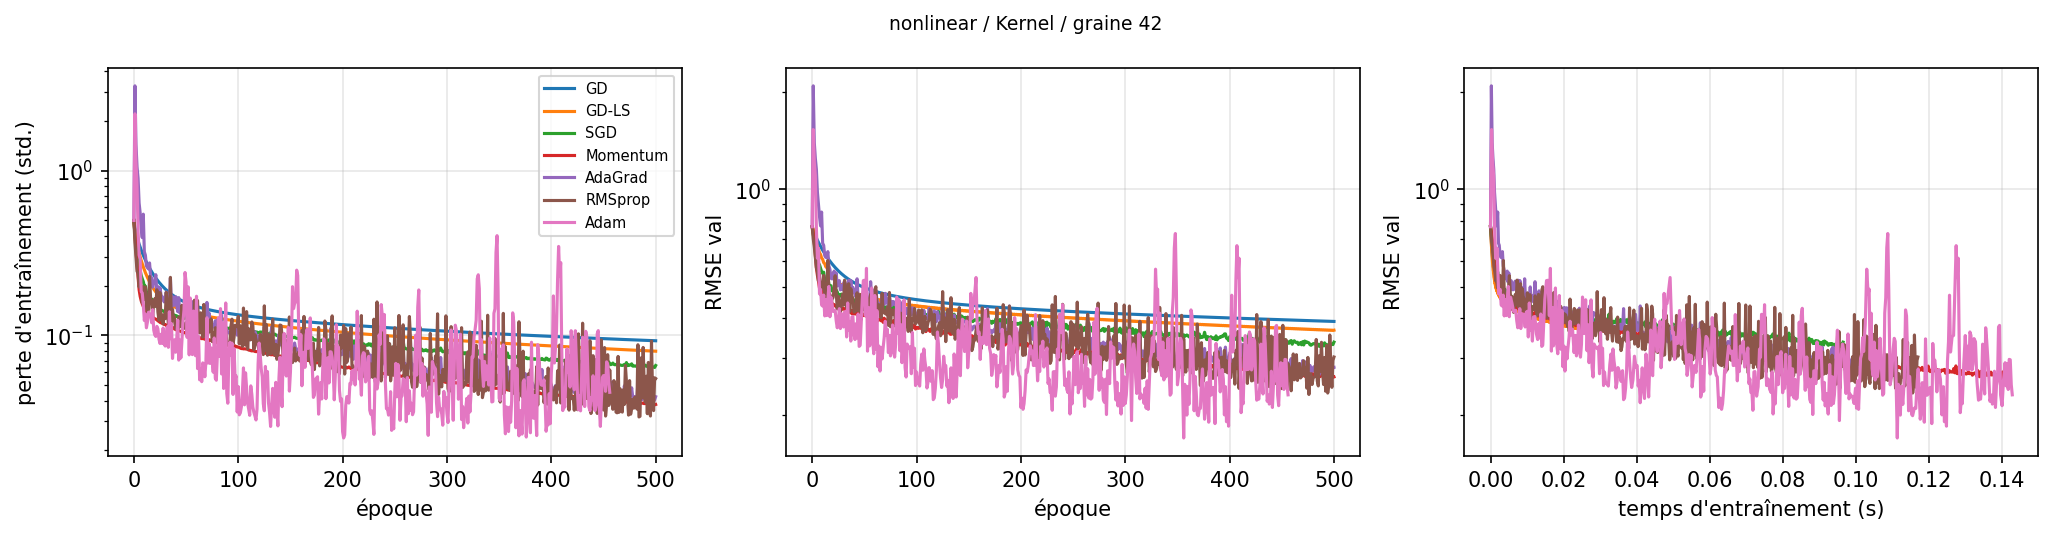

results/figs/reg_nonlinear_OLS_curves.png


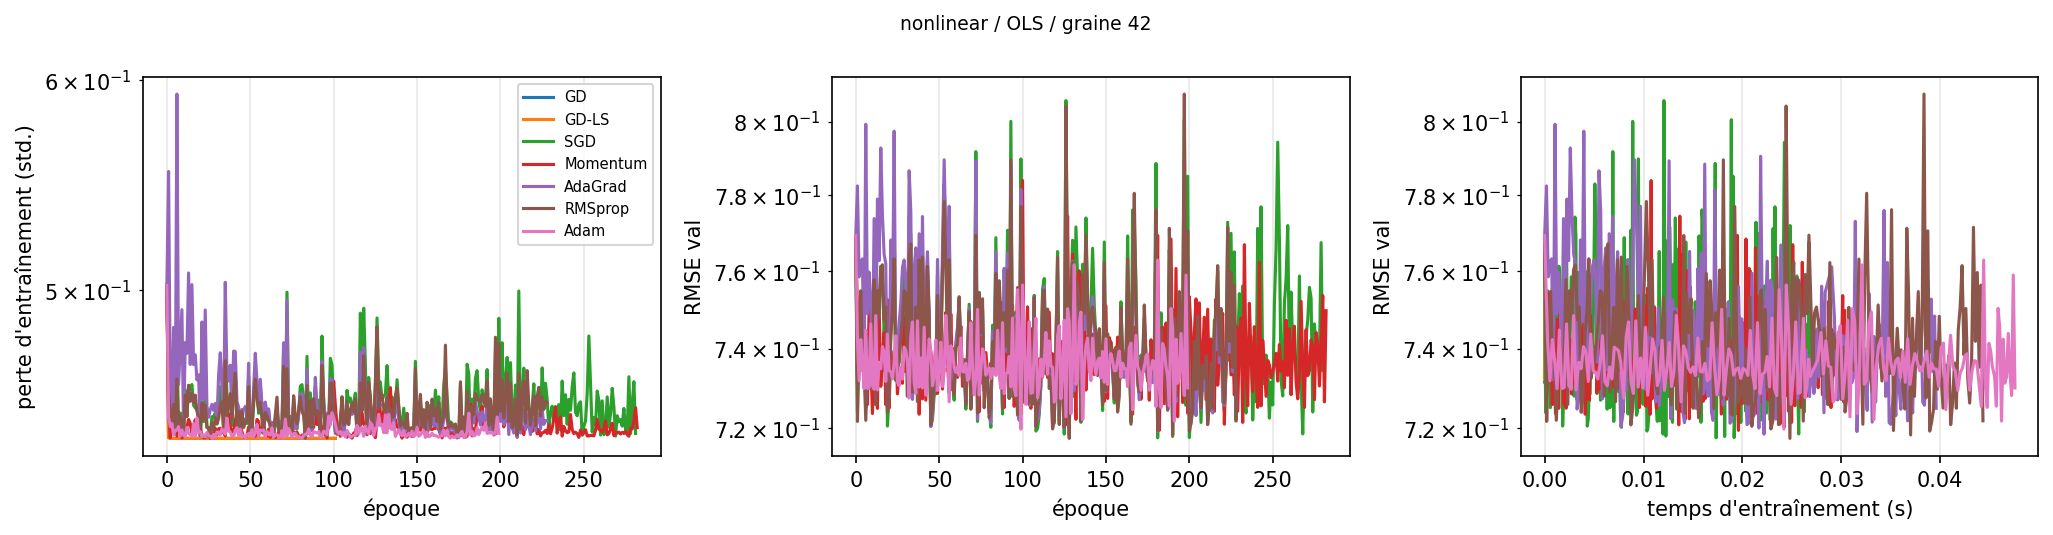

results/figs/reg_nonlinear_Ridge_curves.png


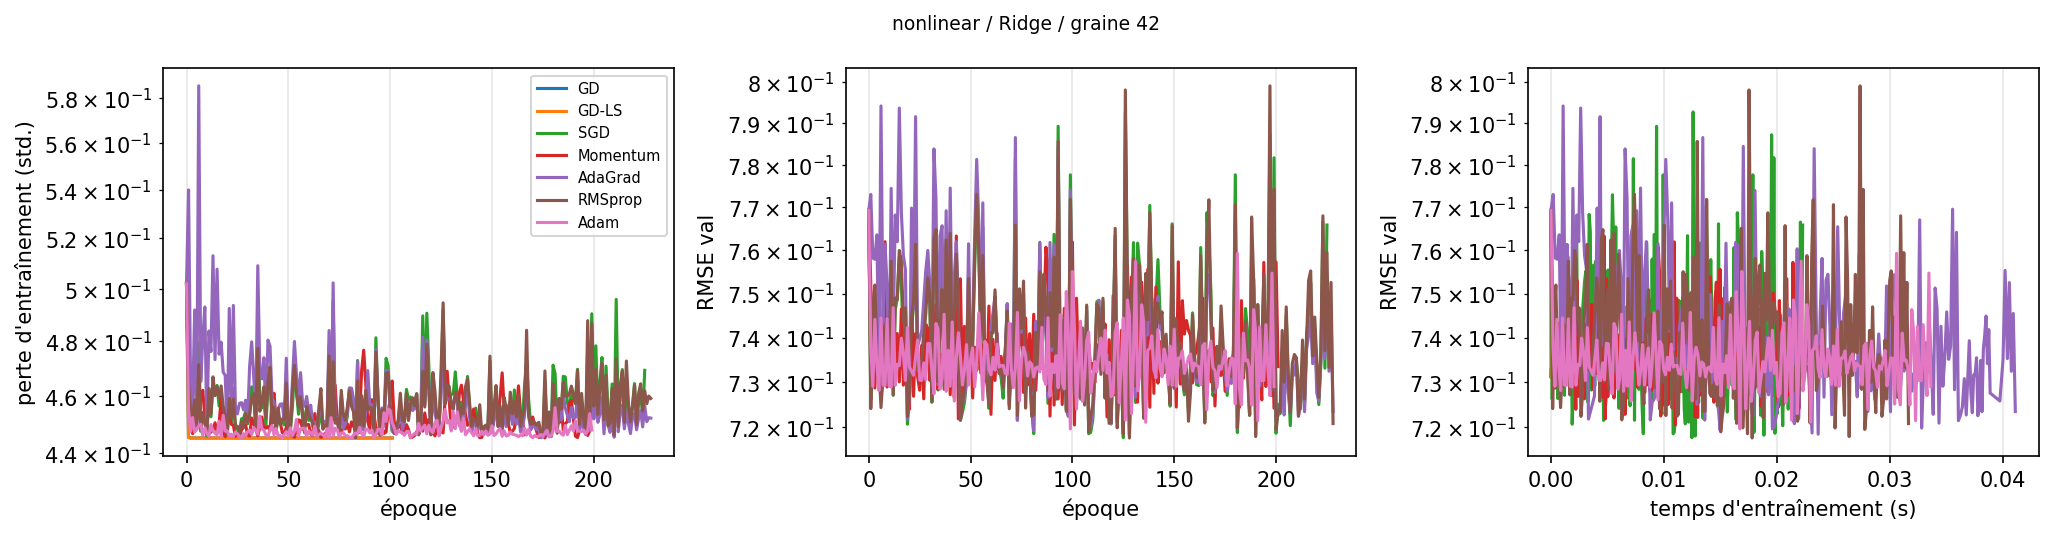

results/figs/reg_nonlinear_pred.png


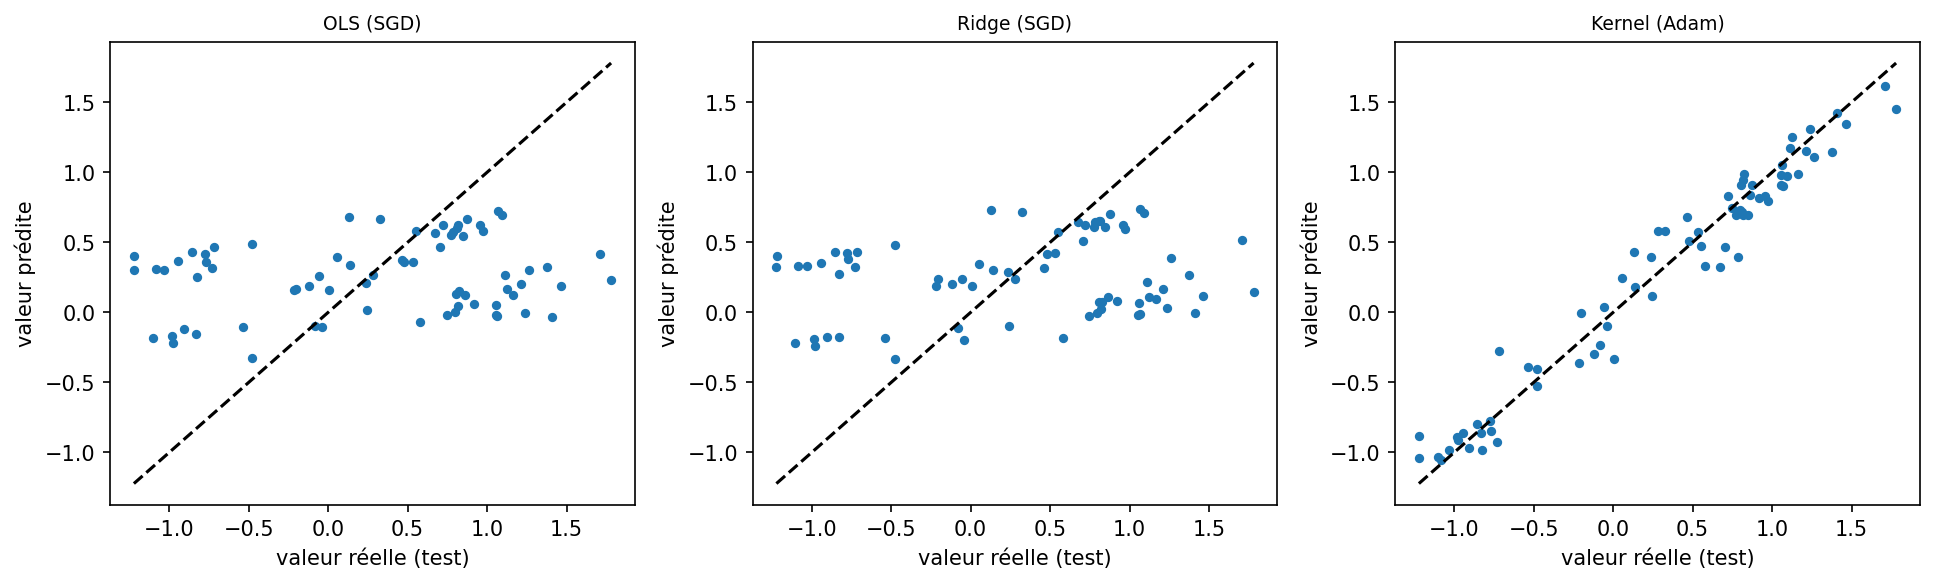

results/figs/reg_nonlinear_resid.png


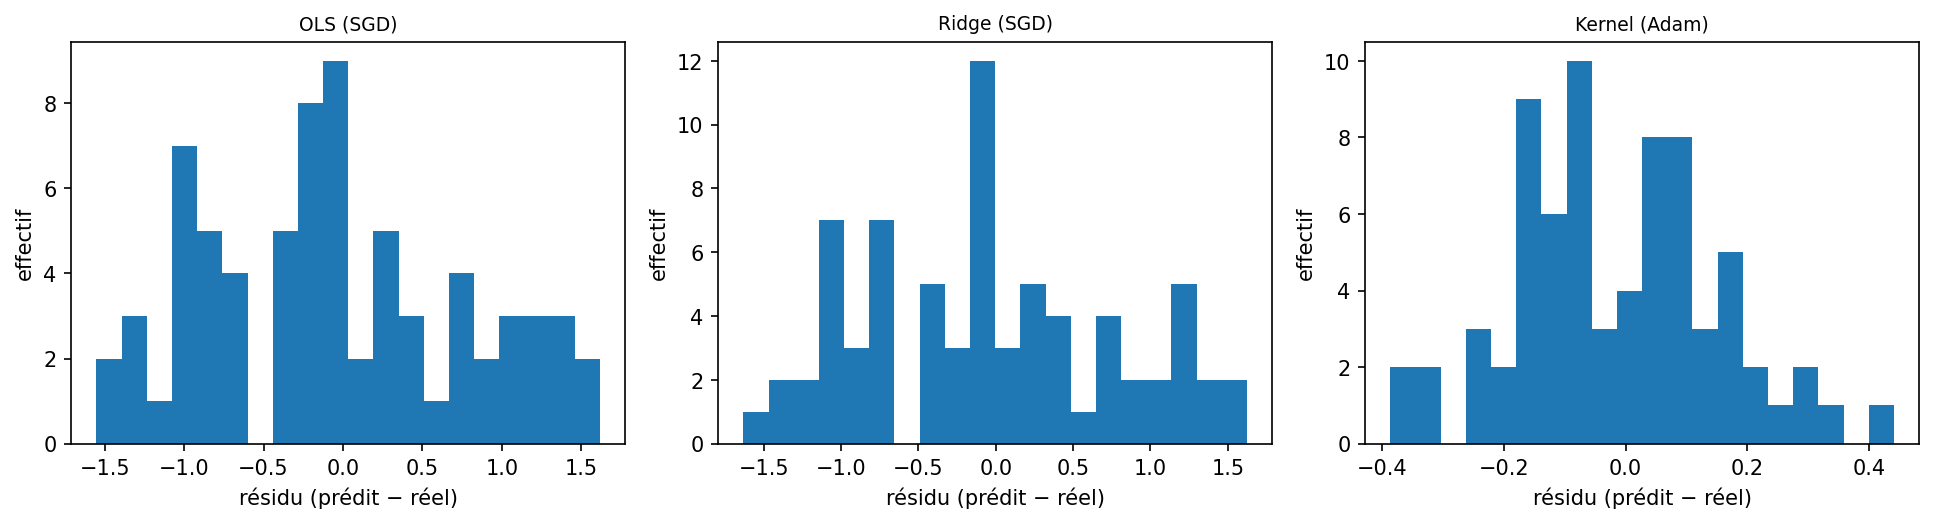

results/figs/reg_nonlinear_surface.png


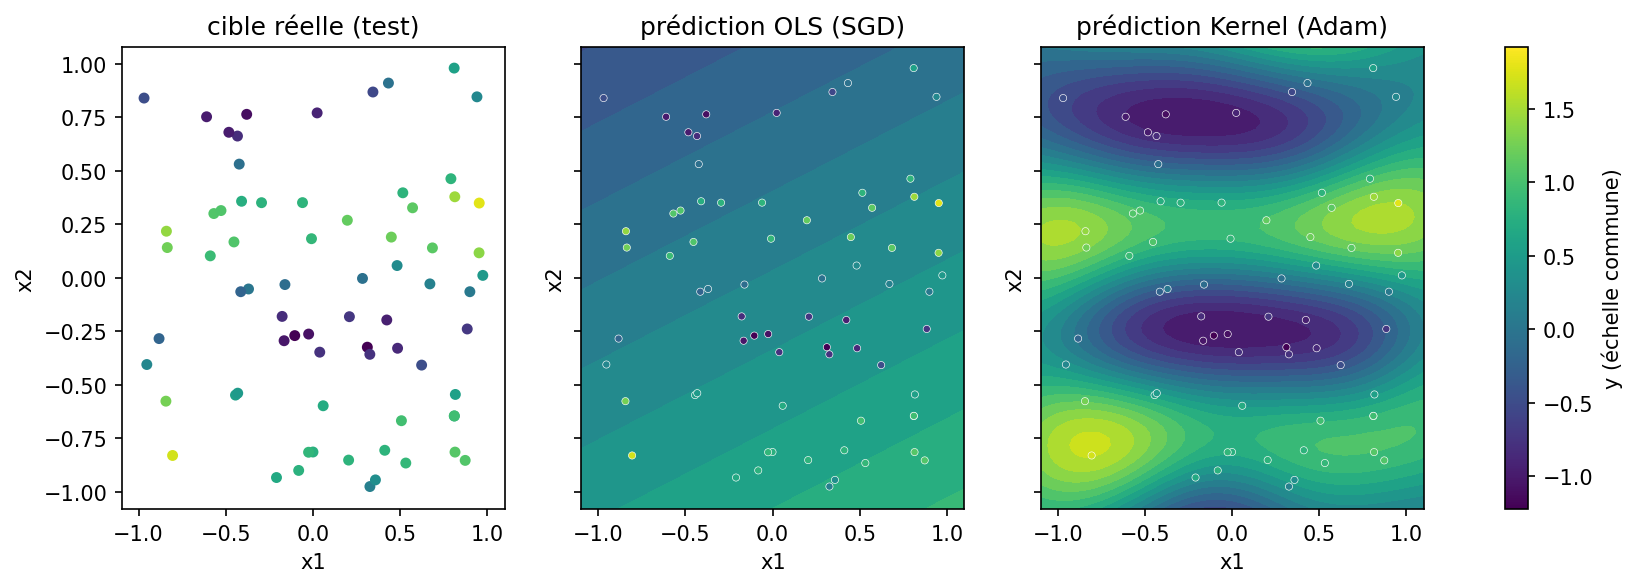

In [15]:
show("reg_nonlinear")


results/figs/reg_diabetes_Kernel_curves.png


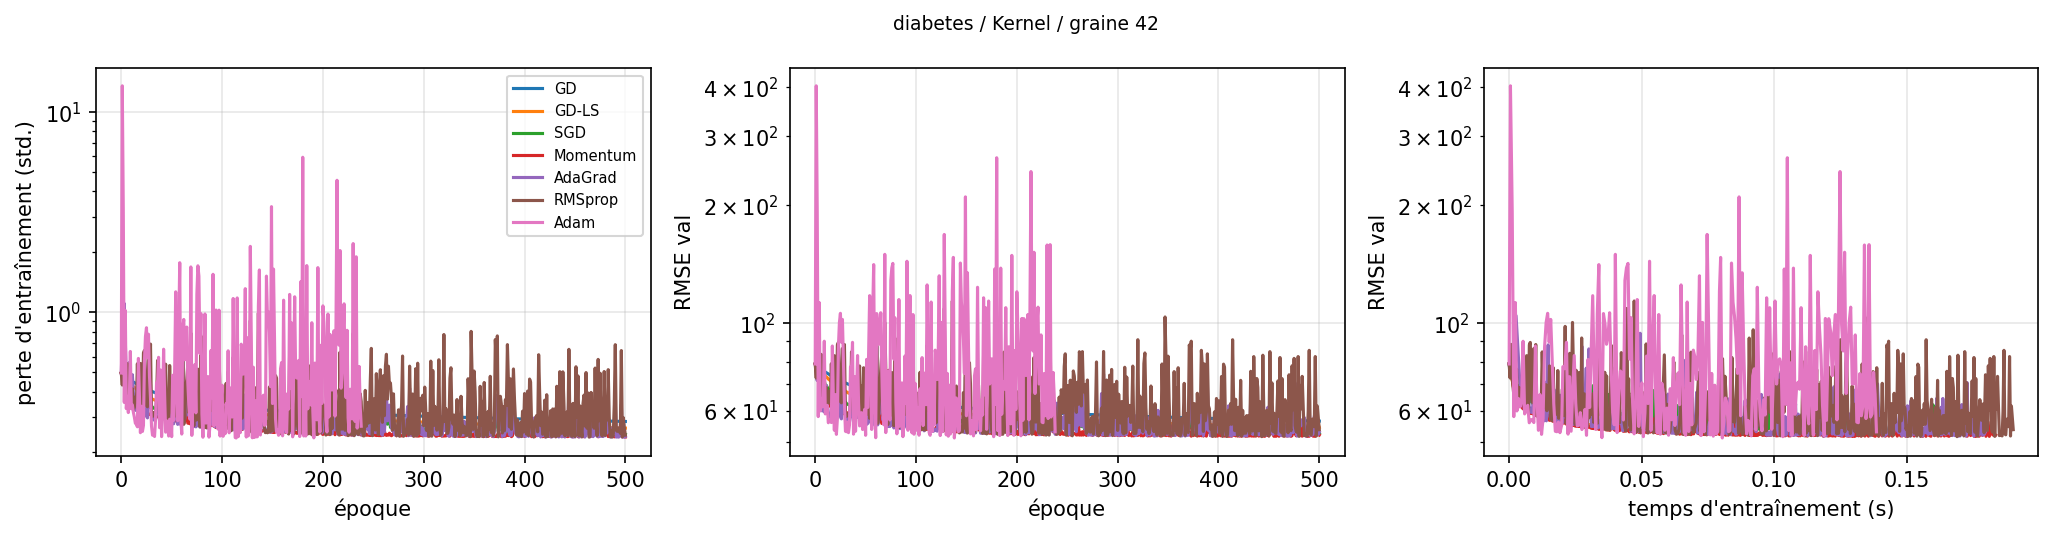

results/figs/reg_diabetes_OLS_curves.png


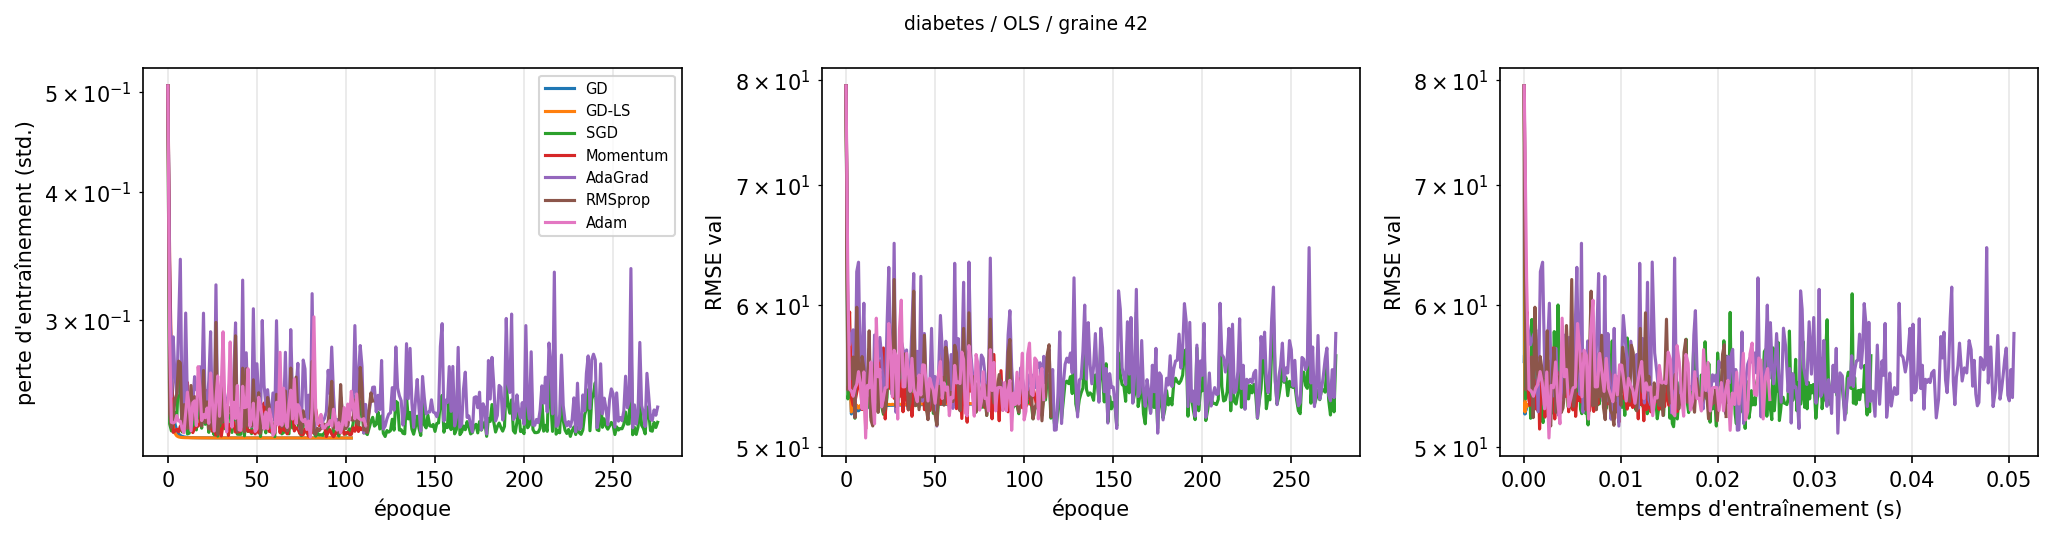

results/figs/reg_diabetes_Ridge_curves.png


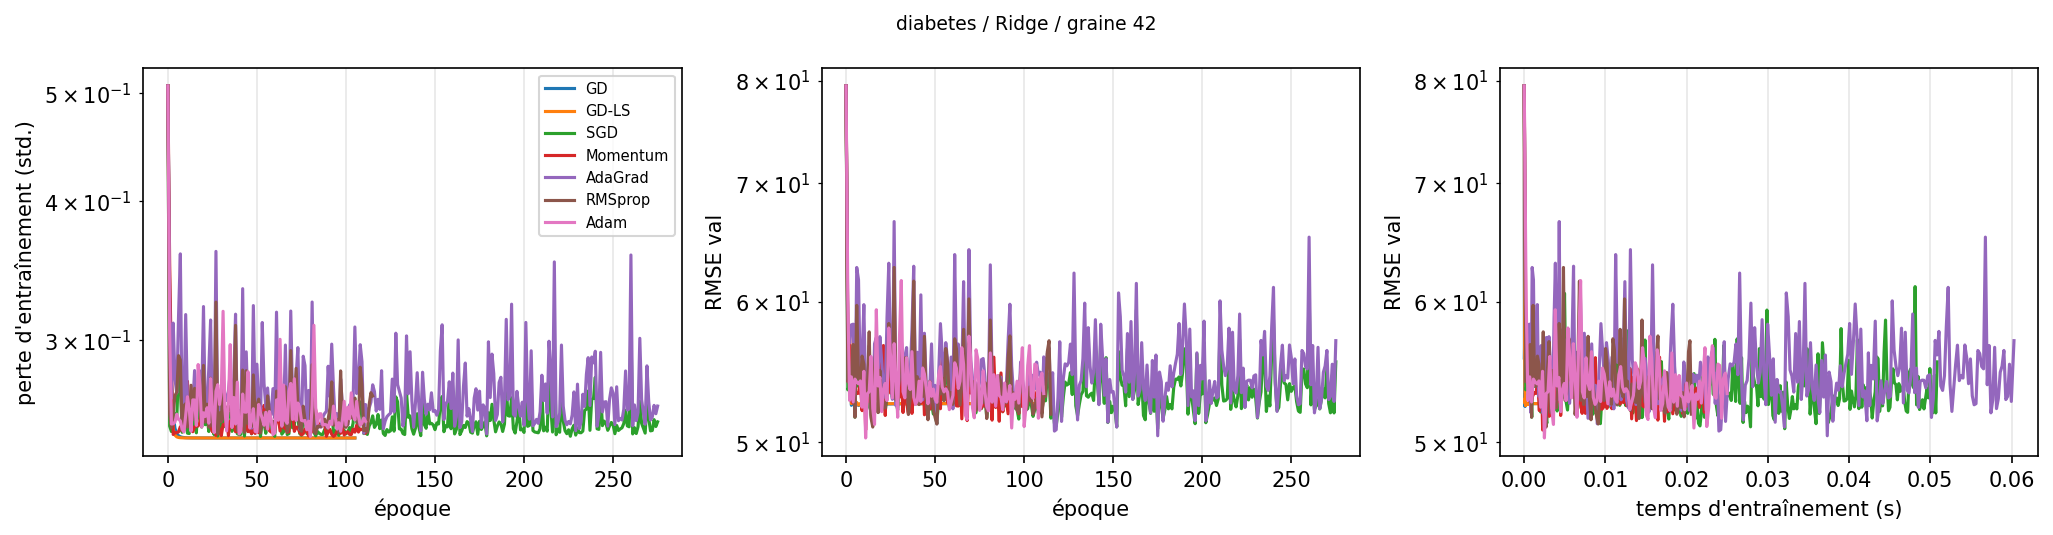

results/figs/reg_diabetes_corr.png


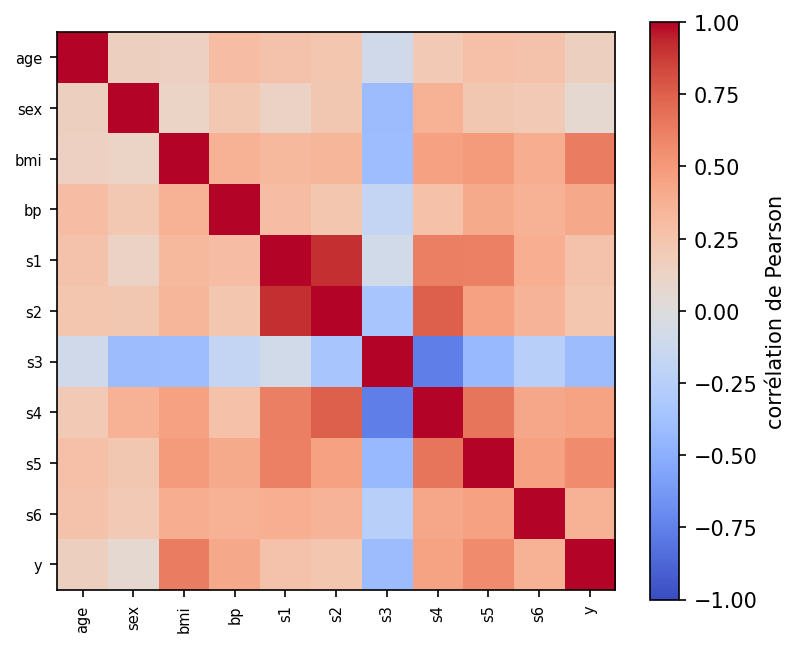

results/figs/reg_diabetes_pred.png


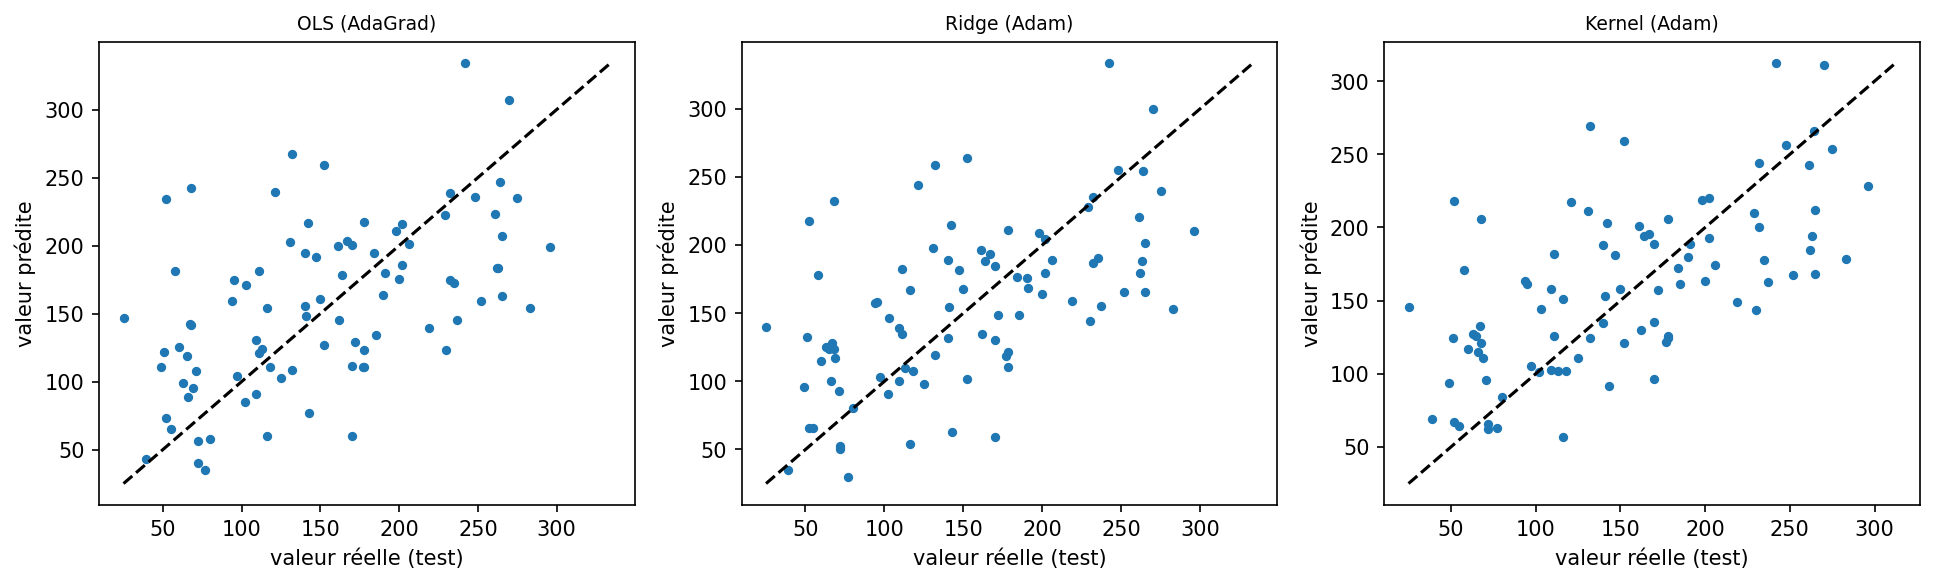

results/figs/reg_diabetes_resid.png


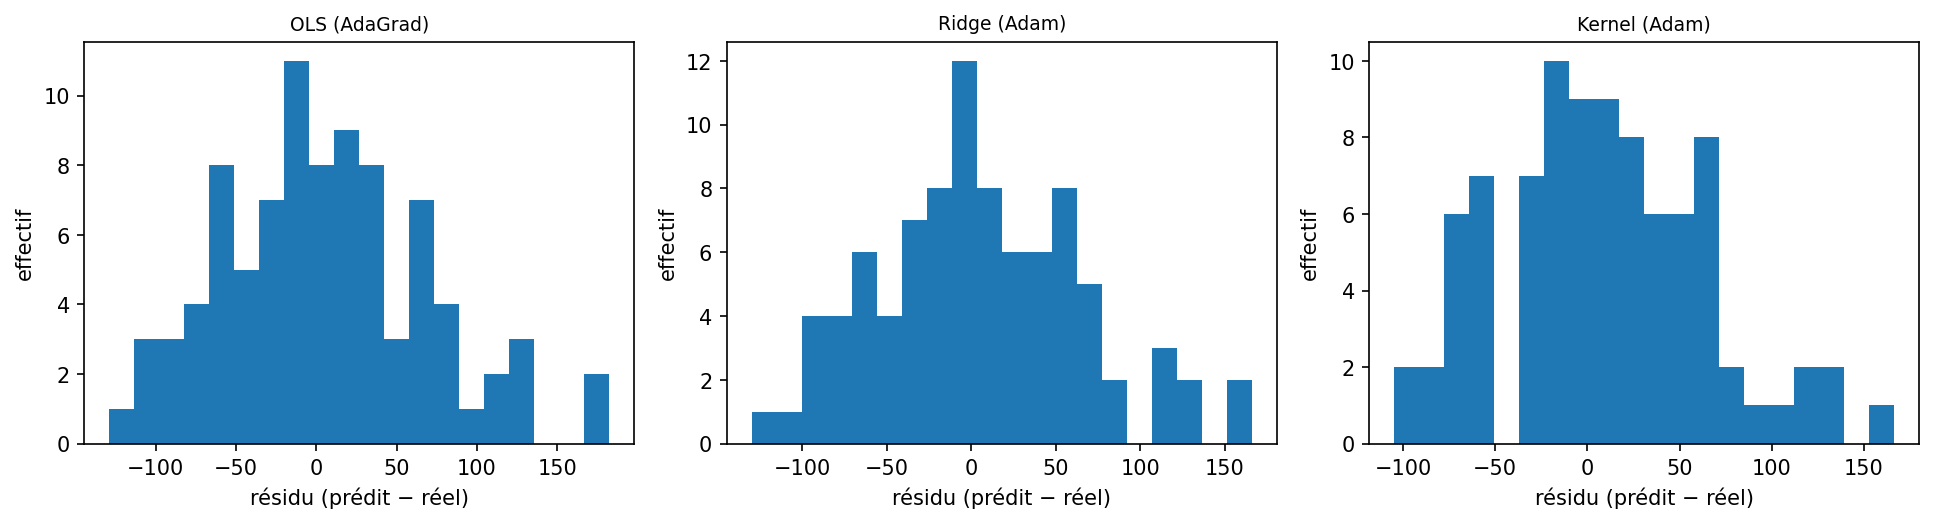

In [16]:
show("reg_diabetes")

results/figs/cls_spiral3_boundary.png


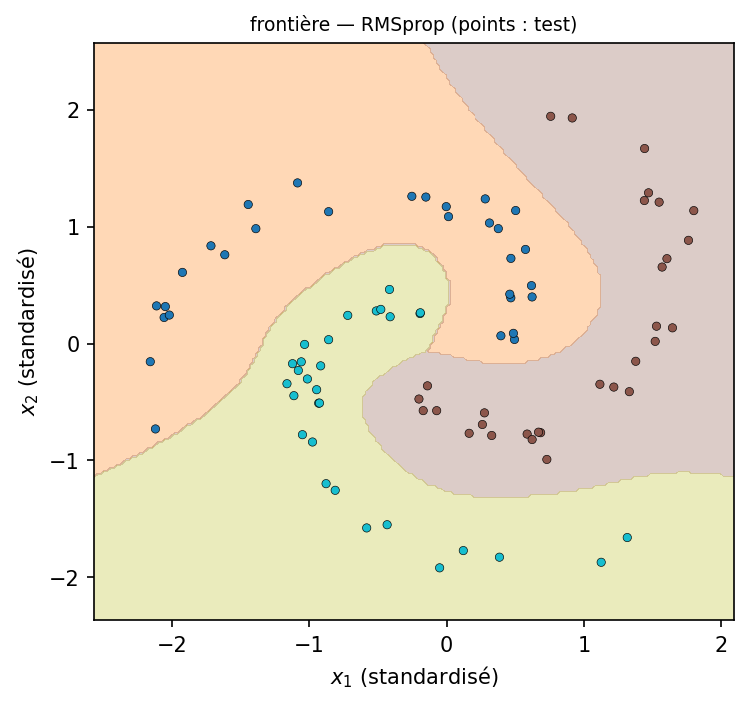

results/figs/cls_spiral3_cm.png


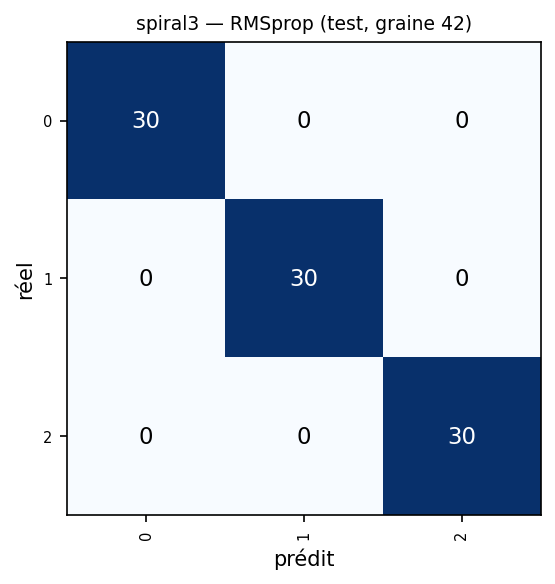

results/figs/cls_spiral3_curves.png


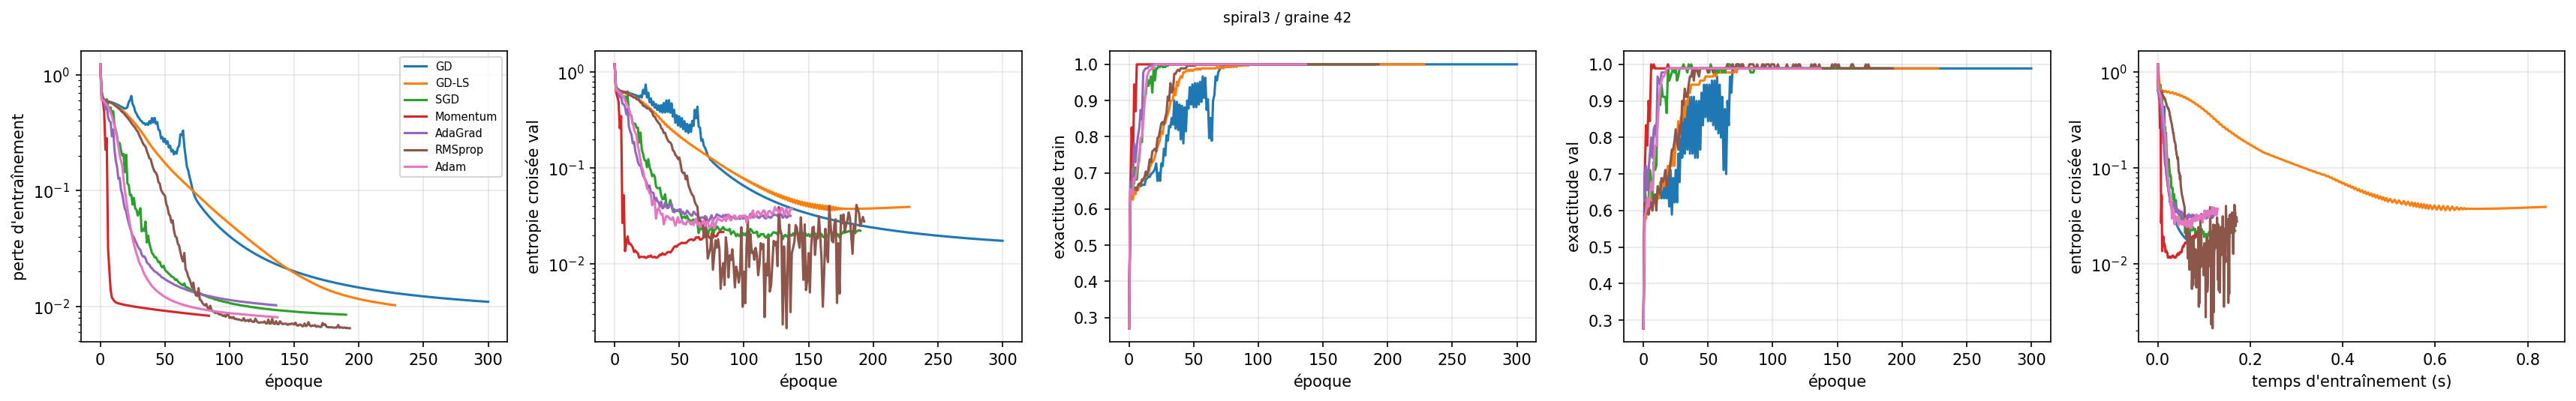

results/figs/cls_spiral3_f1.png


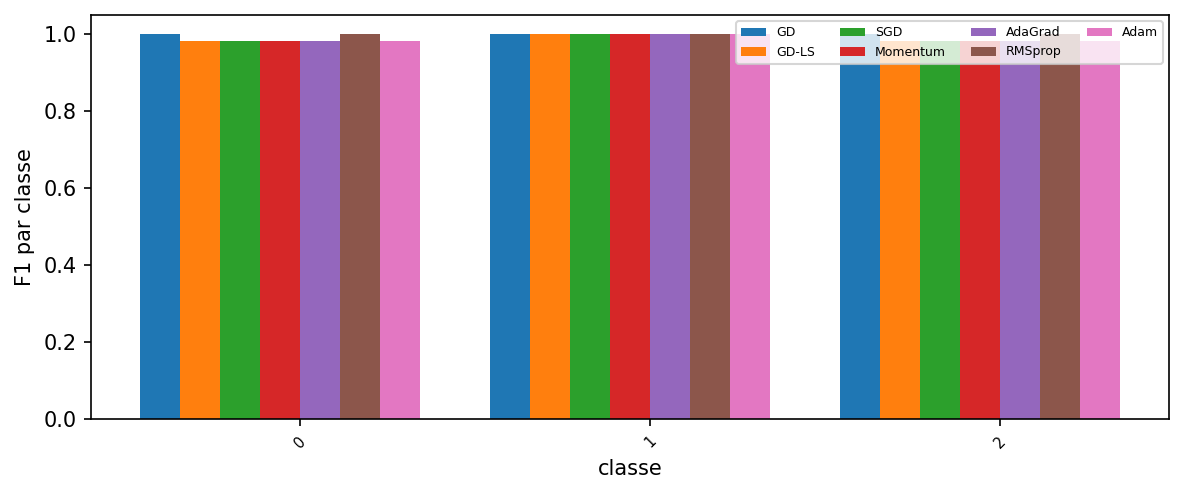

In [17]:
show("cls_spiral3")

results/figs/cls_iris_cm.png


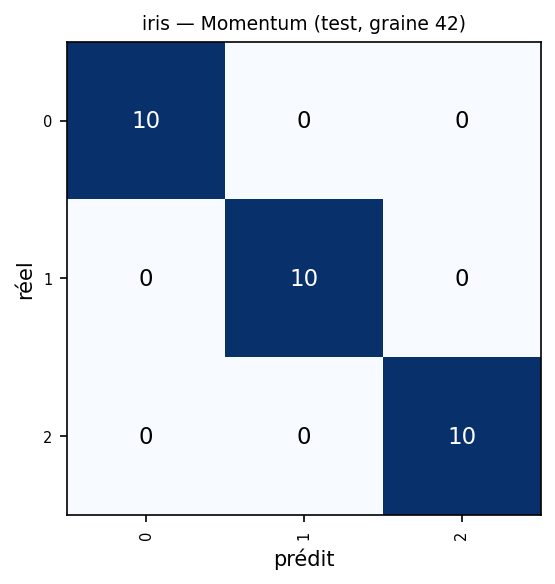

results/figs/cls_iris_curves.png


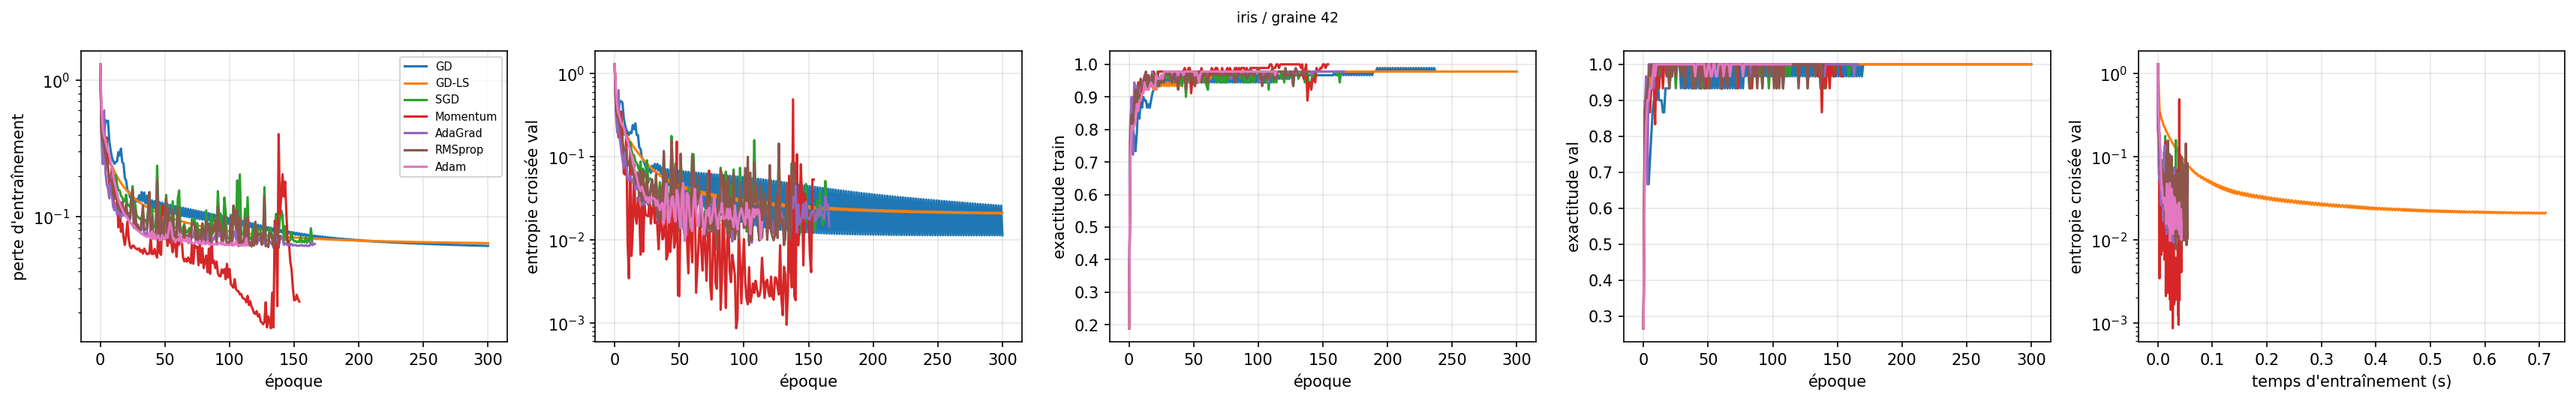

results/figs/cls_iris_f1.png


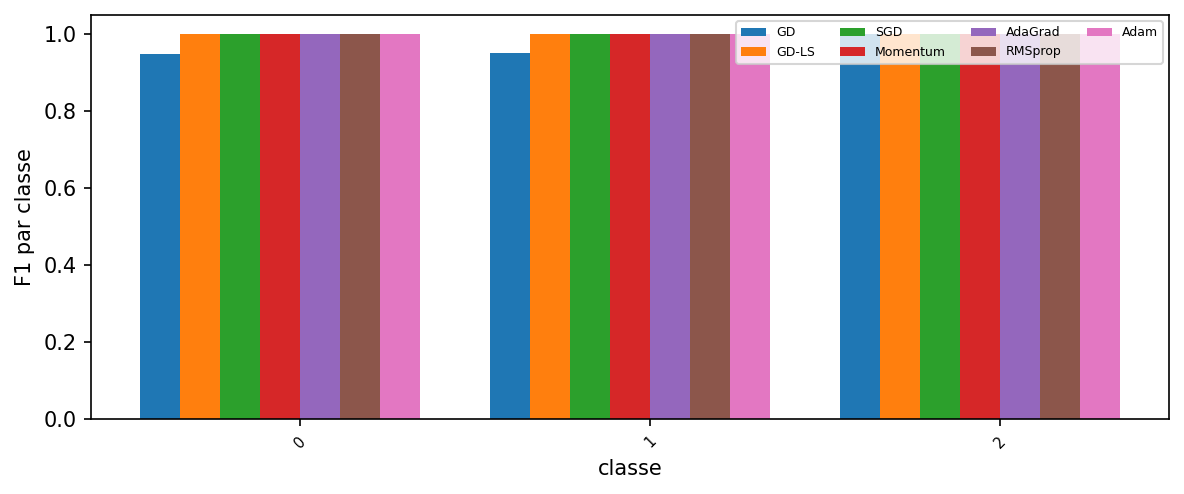

results/figs/cls_iris_pca.png


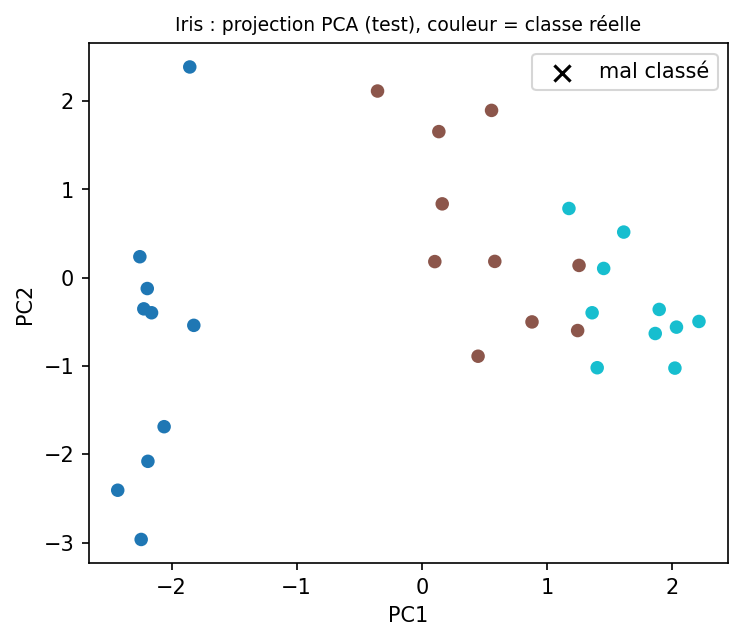

In [18]:
show("cls_iris")

results/figs/cls_mnist_cm.png


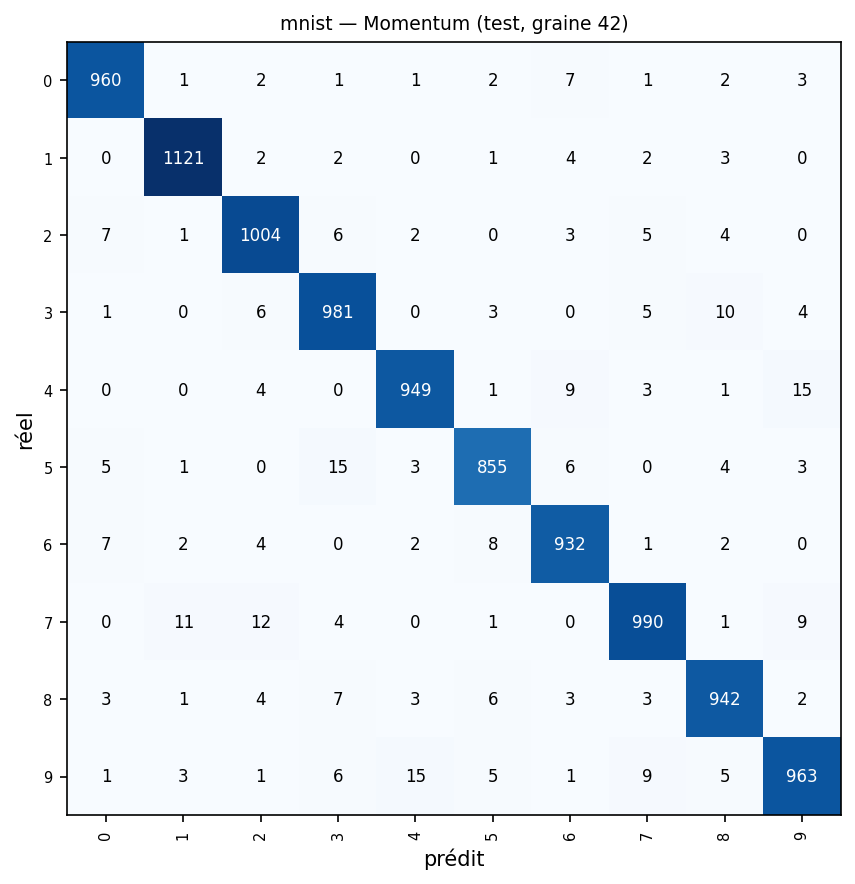

results/figs/cls_mnist_curves.png


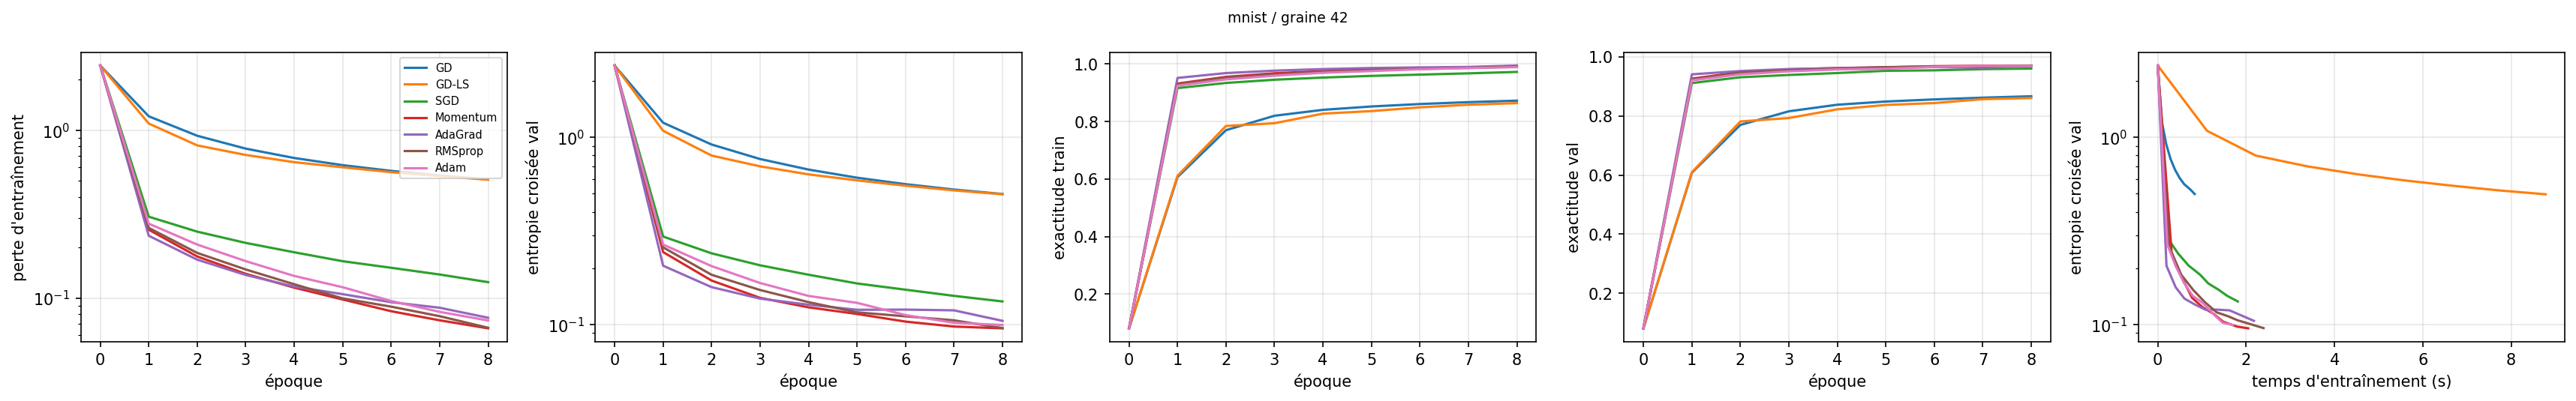

results/figs/cls_mnist_examples.png


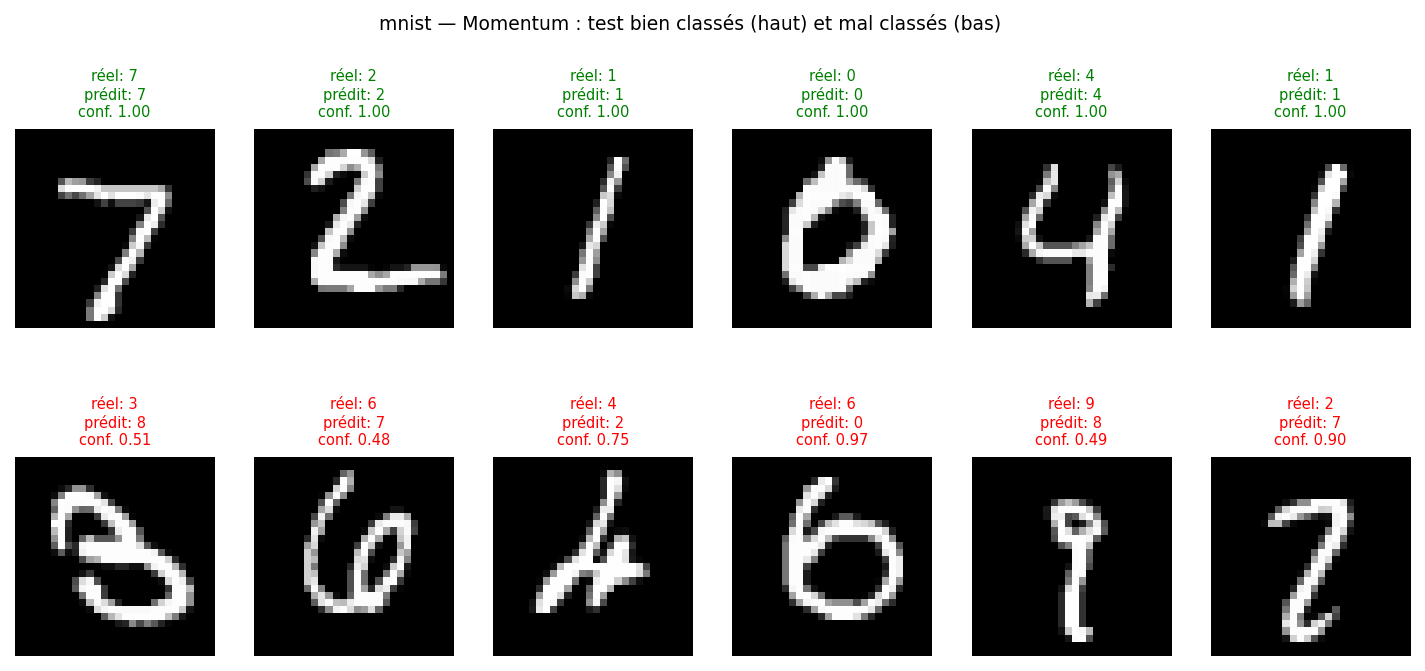

results/figs/cls_mnist_f1.png


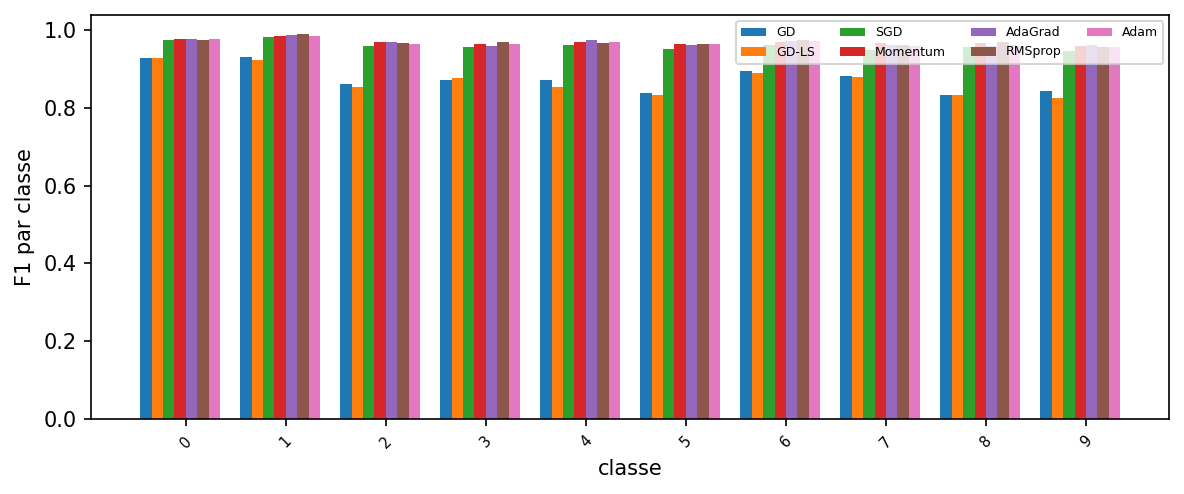

In [19]:
show("cls_mnist")

results/figs/cls_fashion_mnist_cm.png


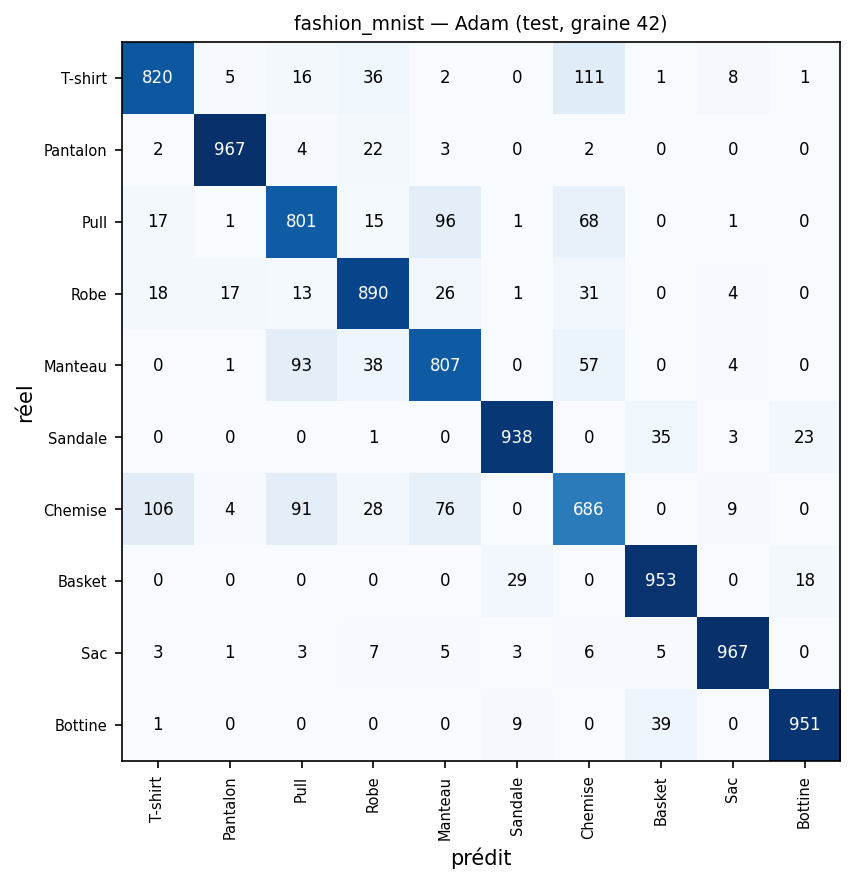

results/figs/cls_fashion_mnist_curves.png


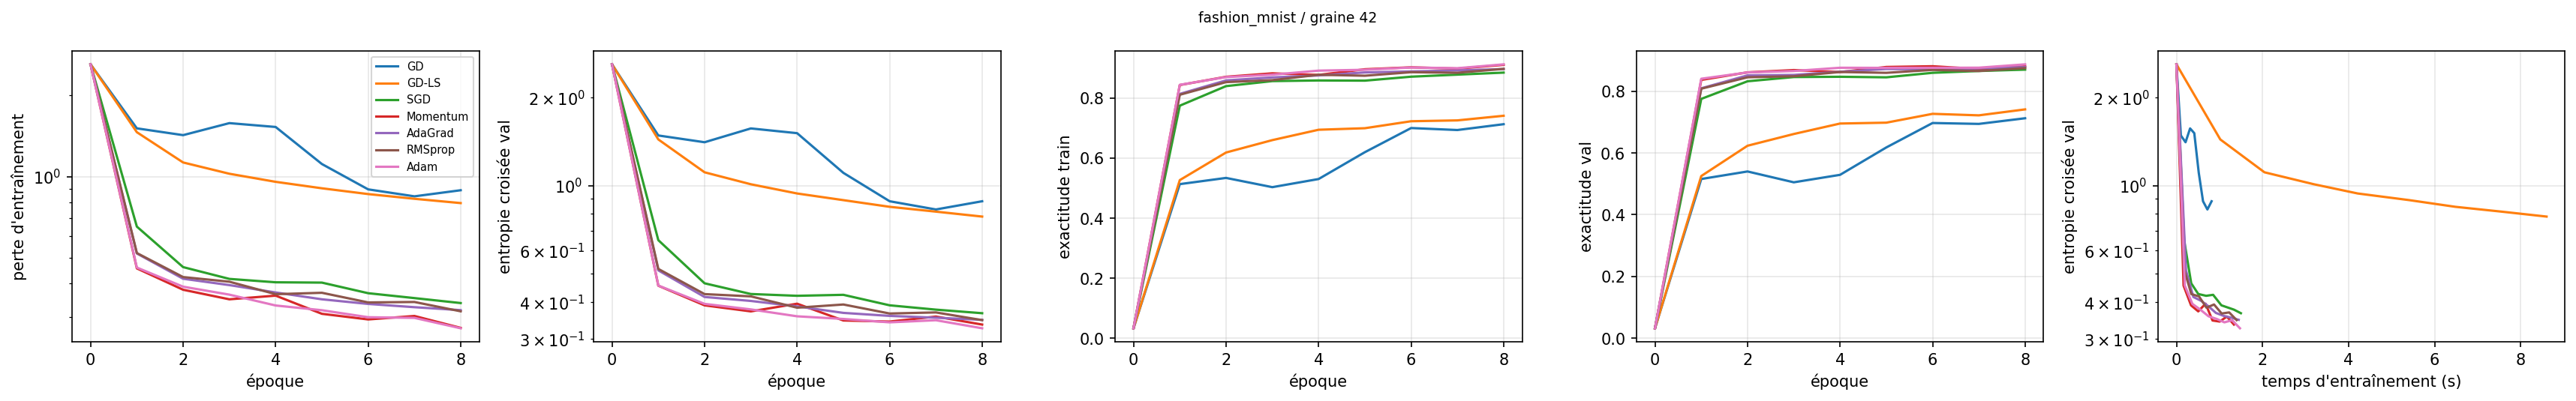

results/figs/cls_fashion_mnist_examples.png


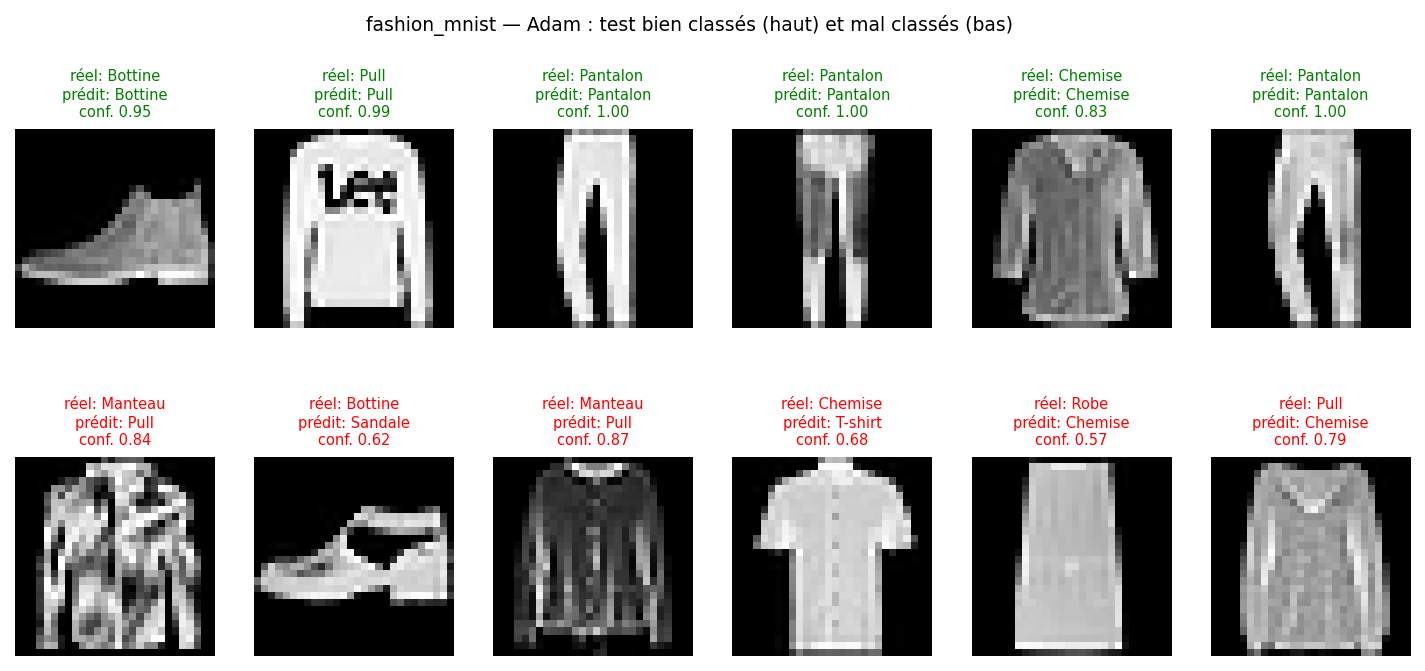

results/figs/cls_fashion_mnist_f1.png


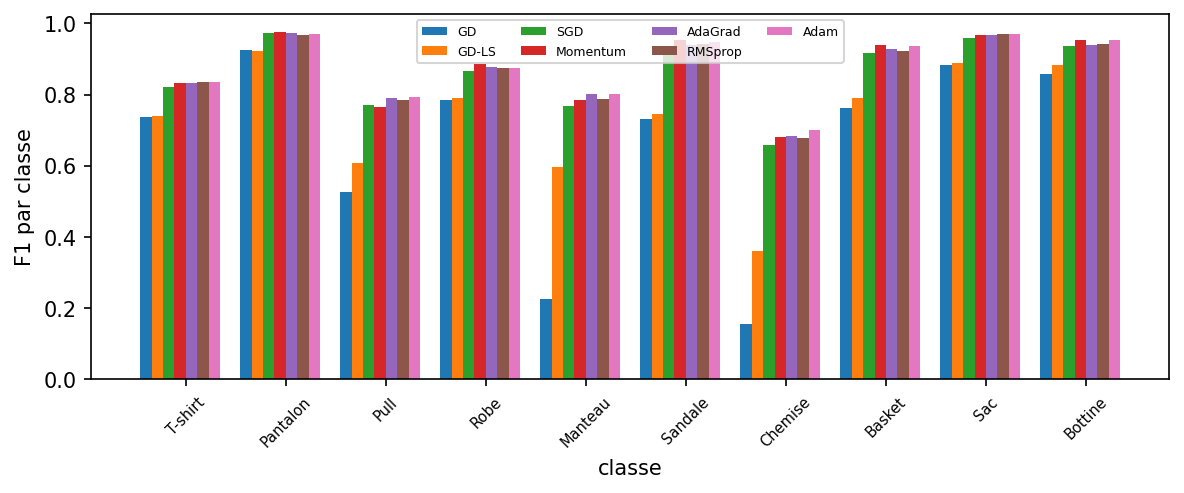

In [20]:
show("cls_fashion_mnist")

results/figs/clu_blobs3_curves.png


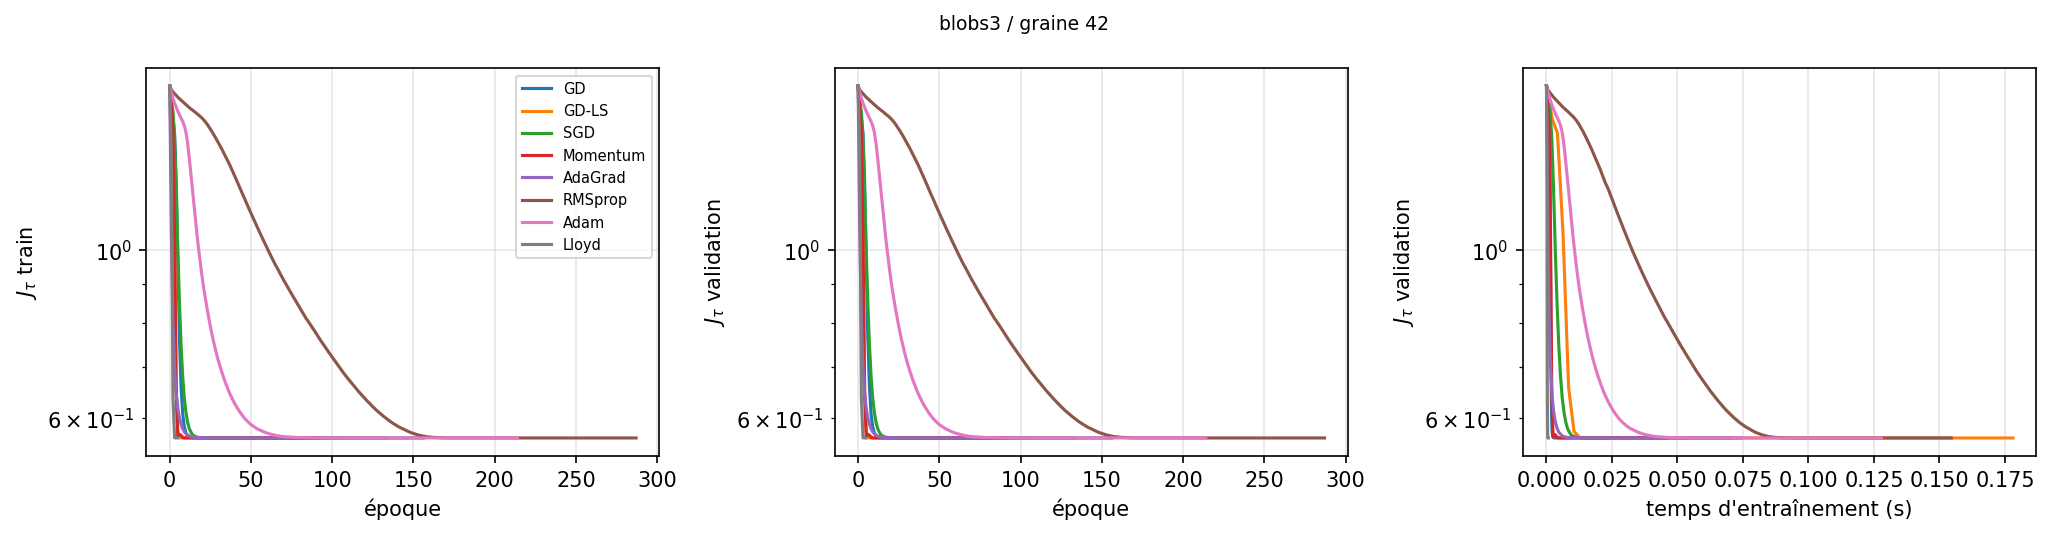

results/figs/clu_blobs3_scatter.png


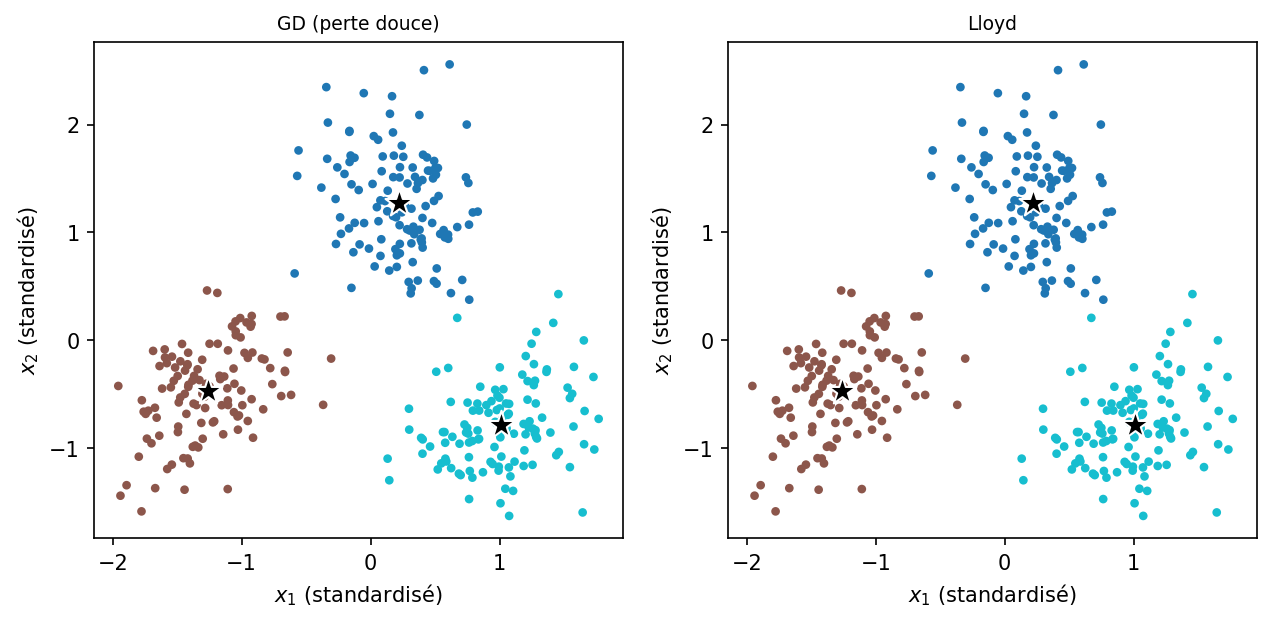

results/figs/clu_blobs3_sizes.png


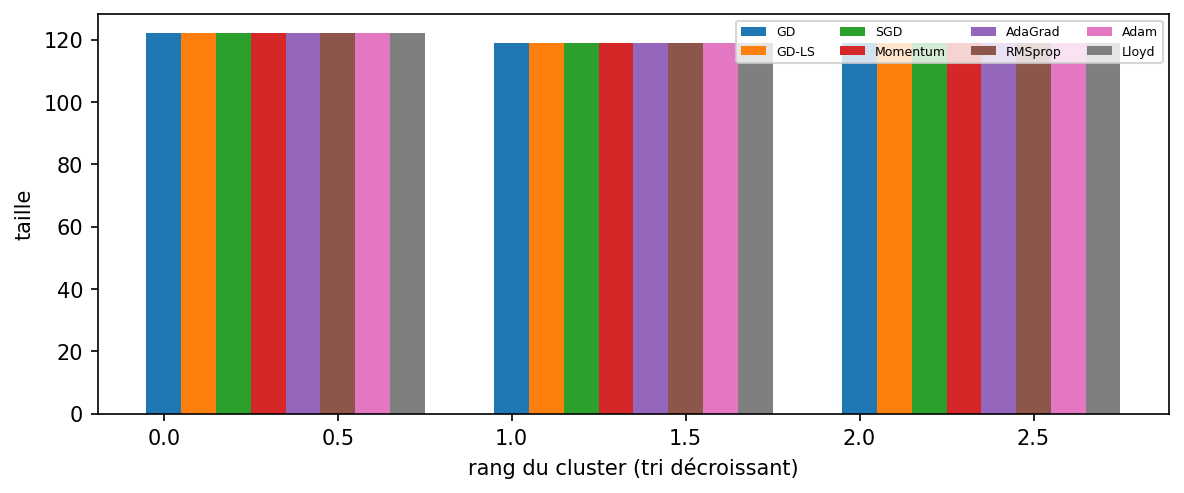

In [21]:
show("clu_blobs3")

results/figs/clu_wine_curves.png


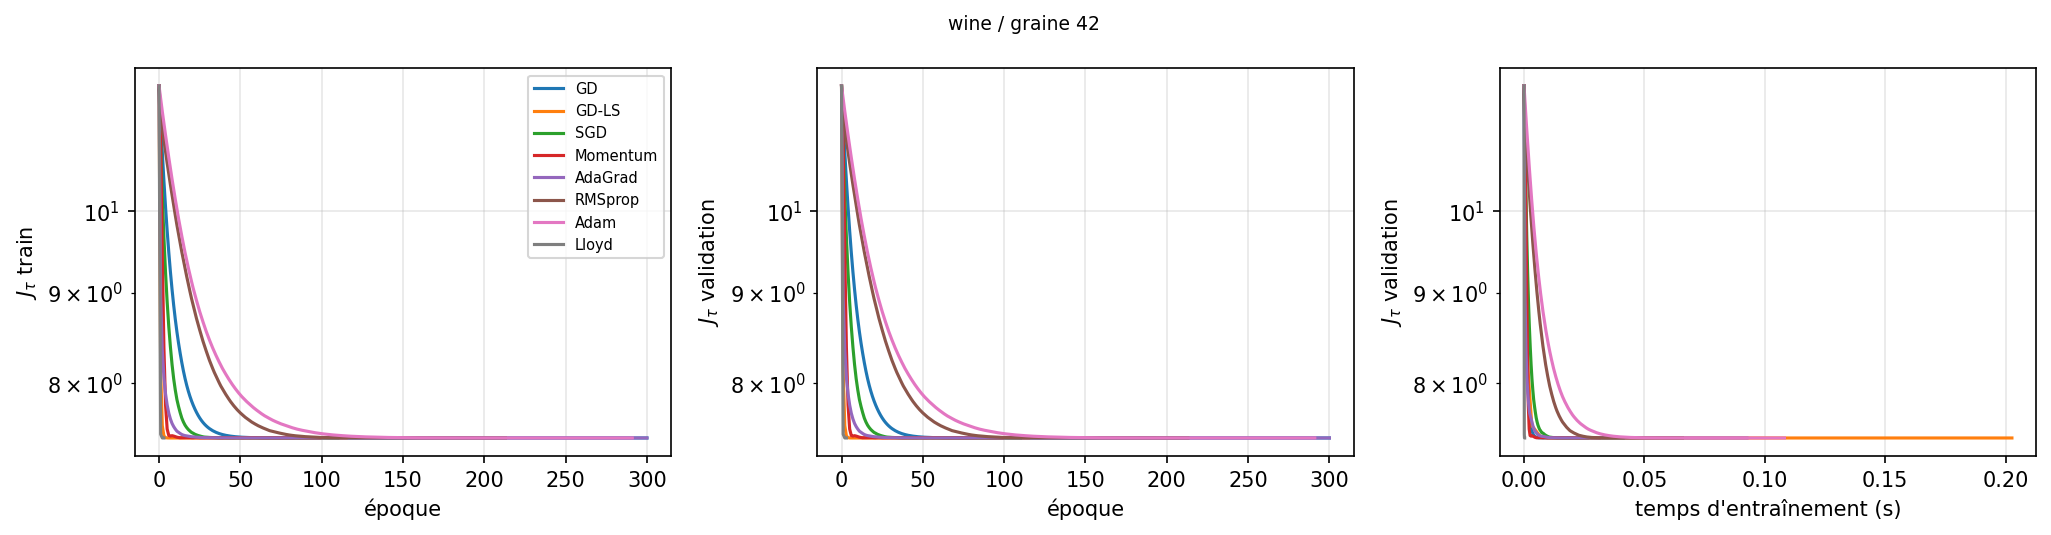

results/figs/clu_wine_pca.png


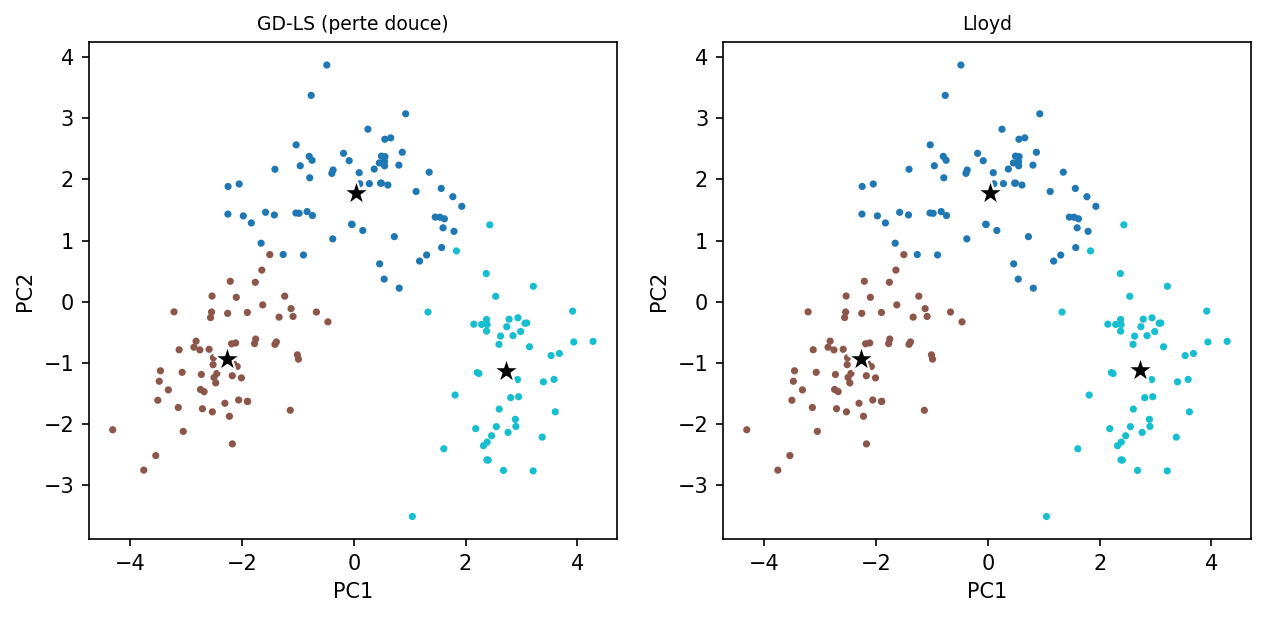

results/figs/clu_wine_sizes.png


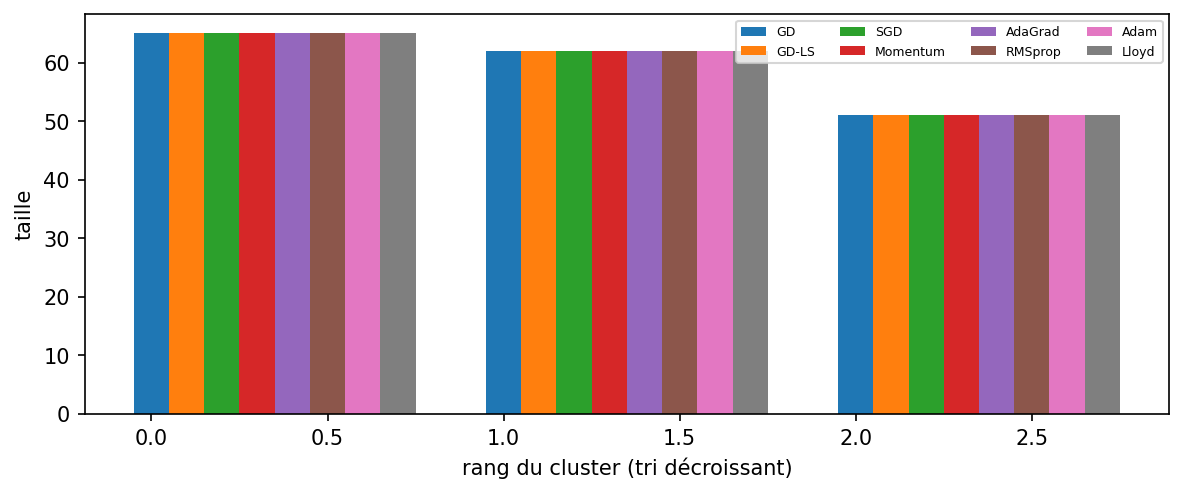

In [22]:
show("clu_wine")

results/figs/clu_mnist_centroids.png


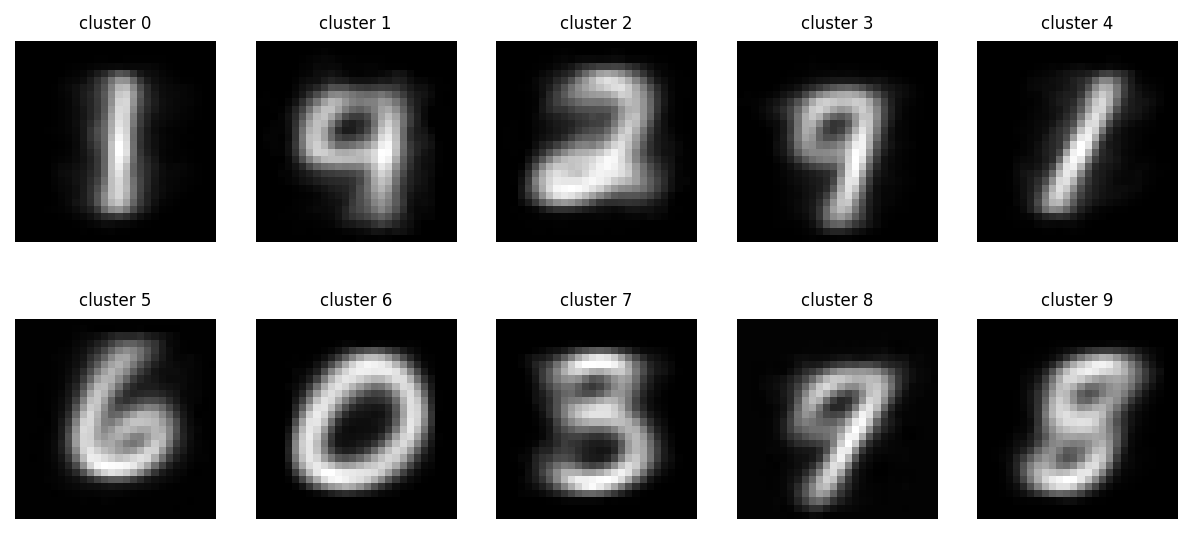

results/figs/clu_mnist_curves.png


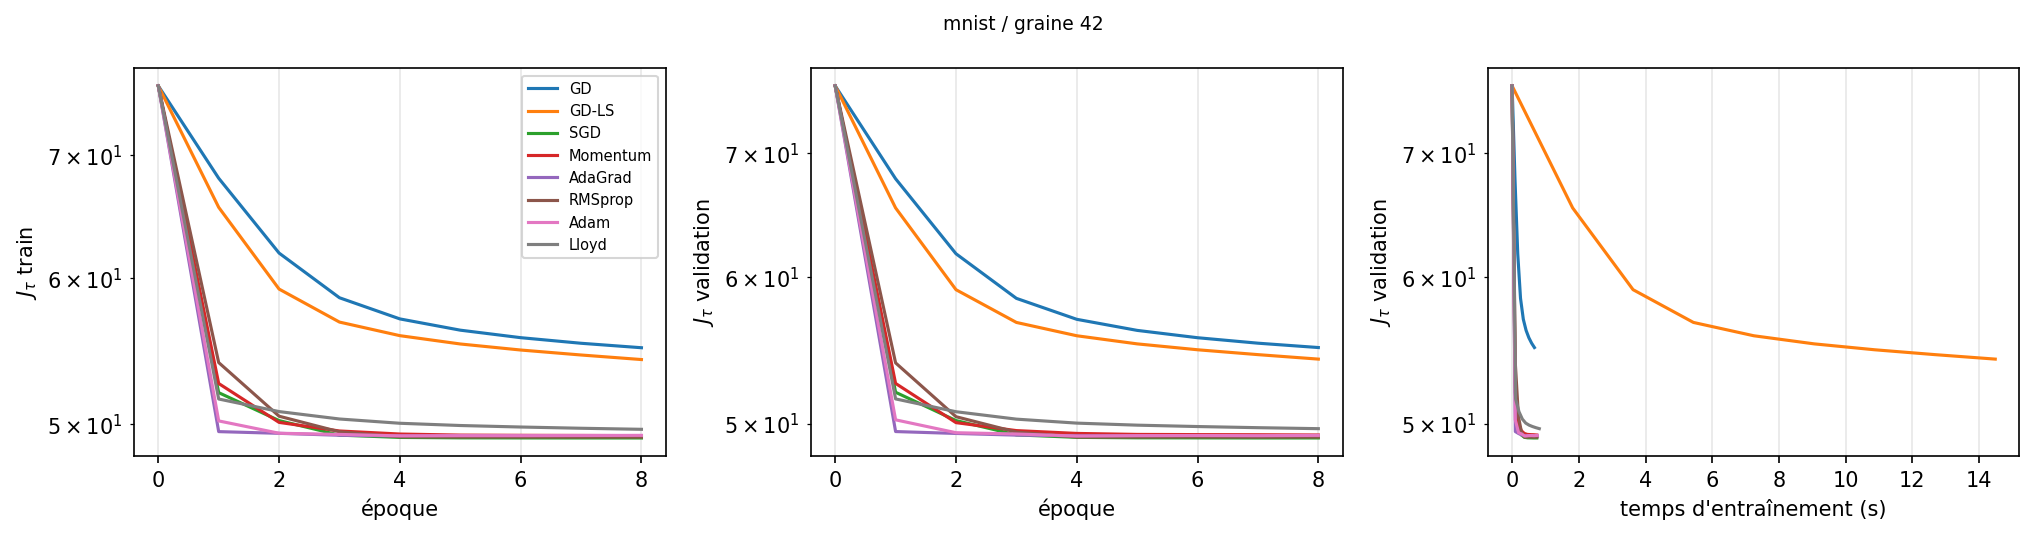

results/figs/clu_mnist_examples.png


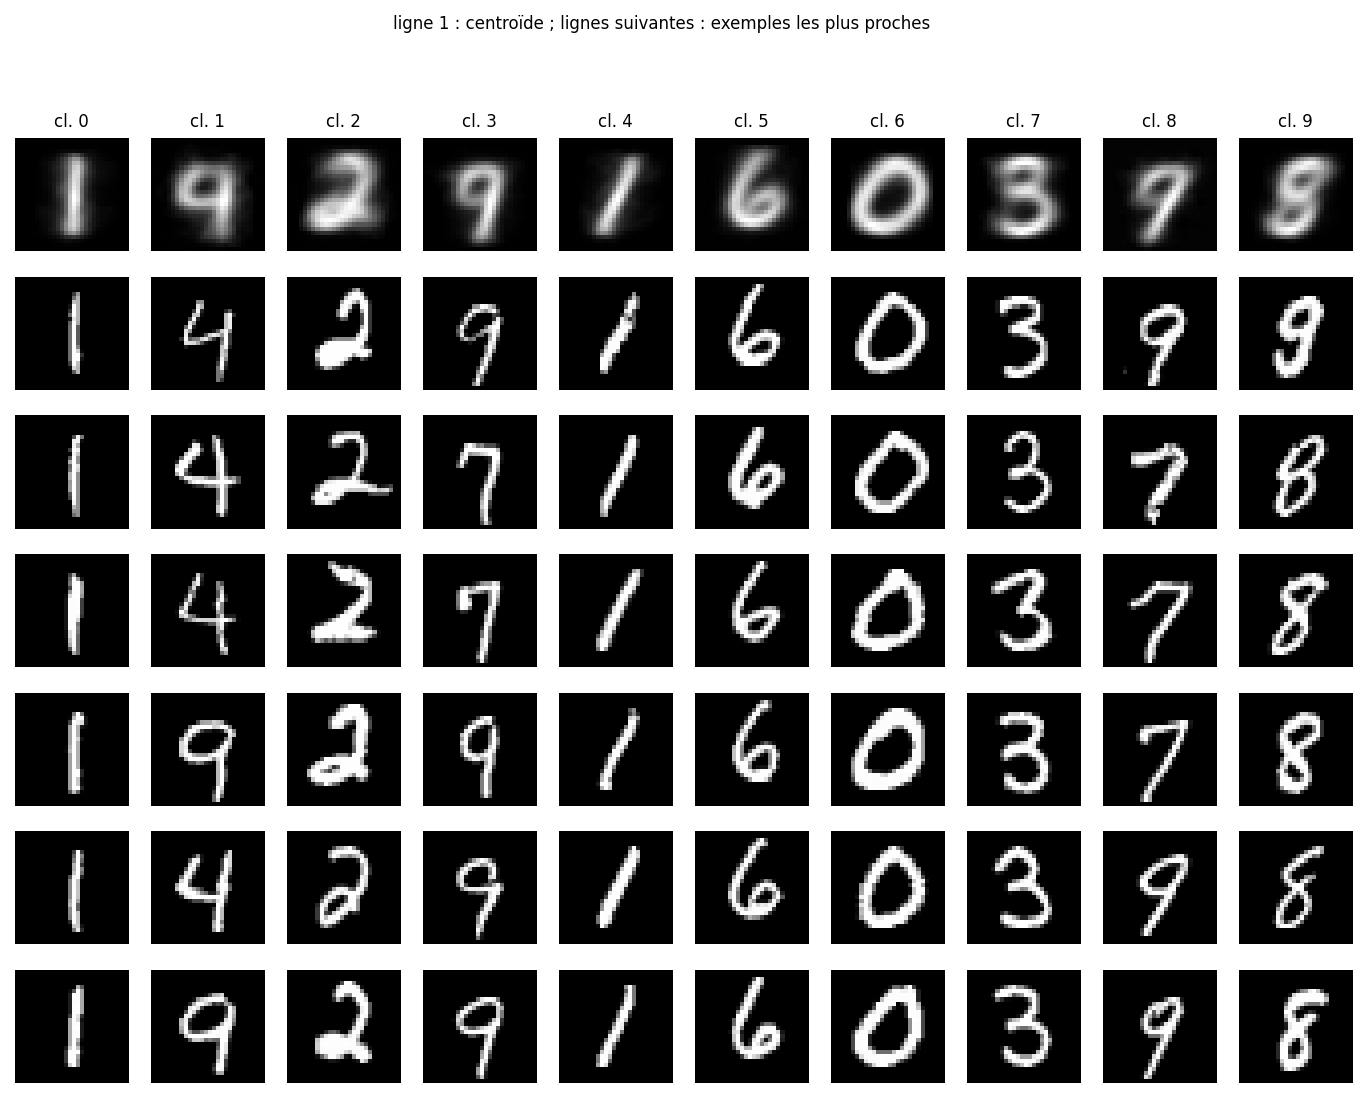

results/figs/clu_mnist_pca.png


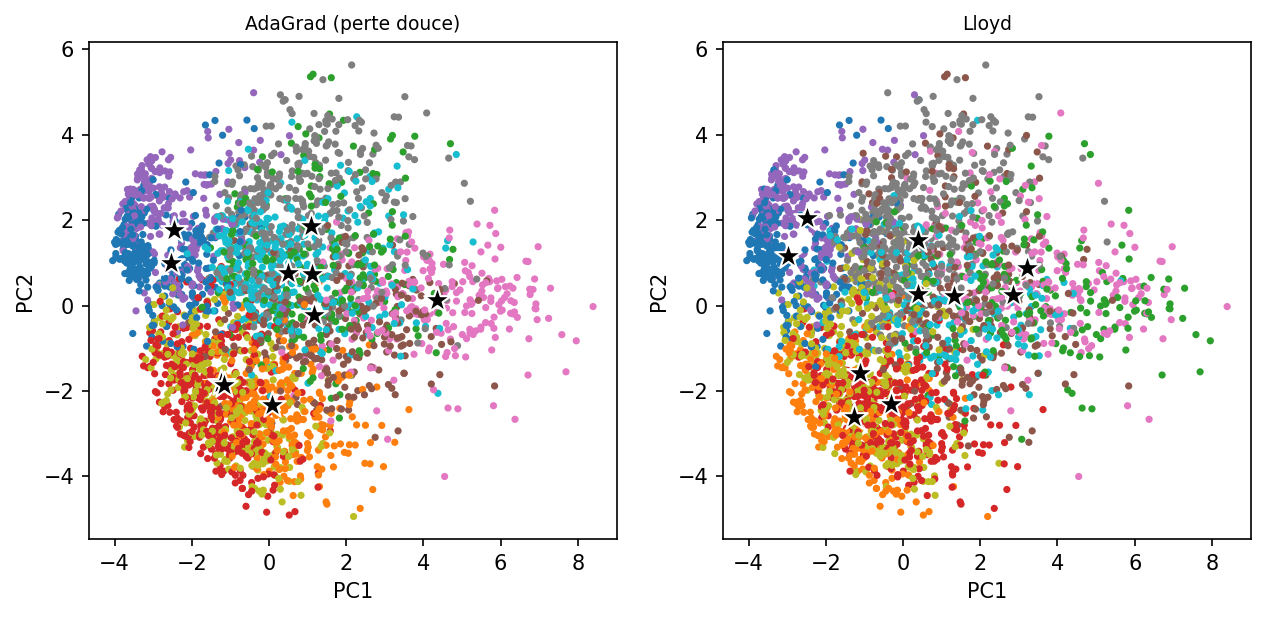

results/figs/clu_mnist_sizes.png


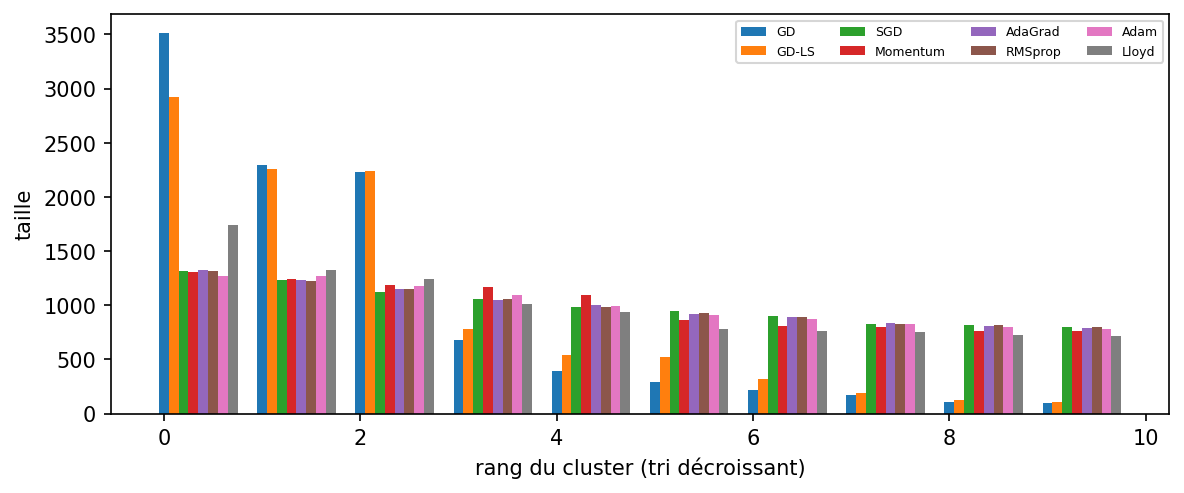

In [23]:
show("clu_mnist")

results/figs/clu_fashion_mnist_centroids.png


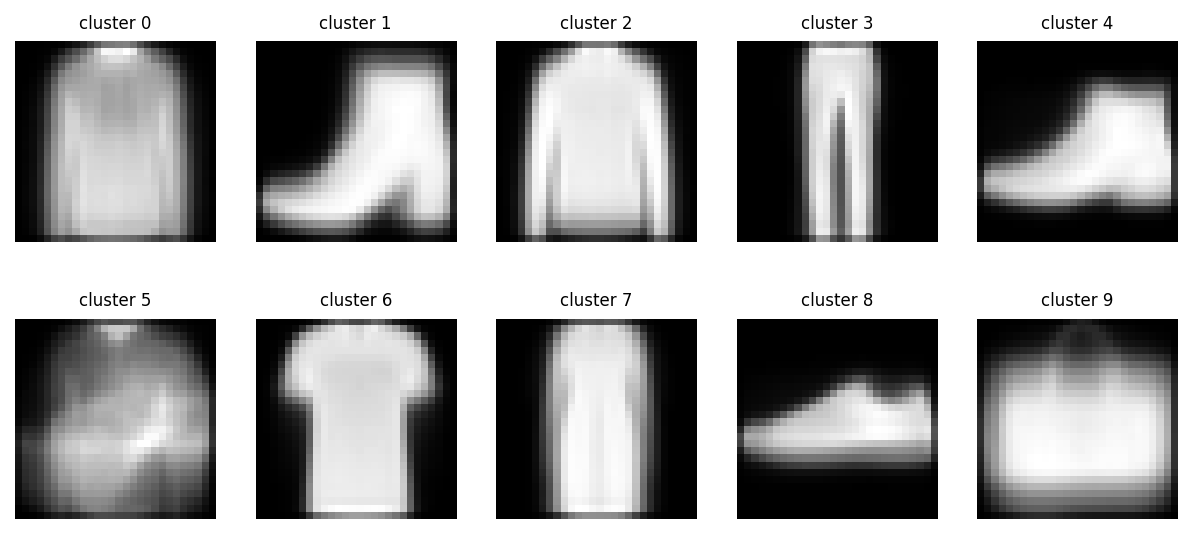

results/figs/clu_fashion_mnist_curves.png


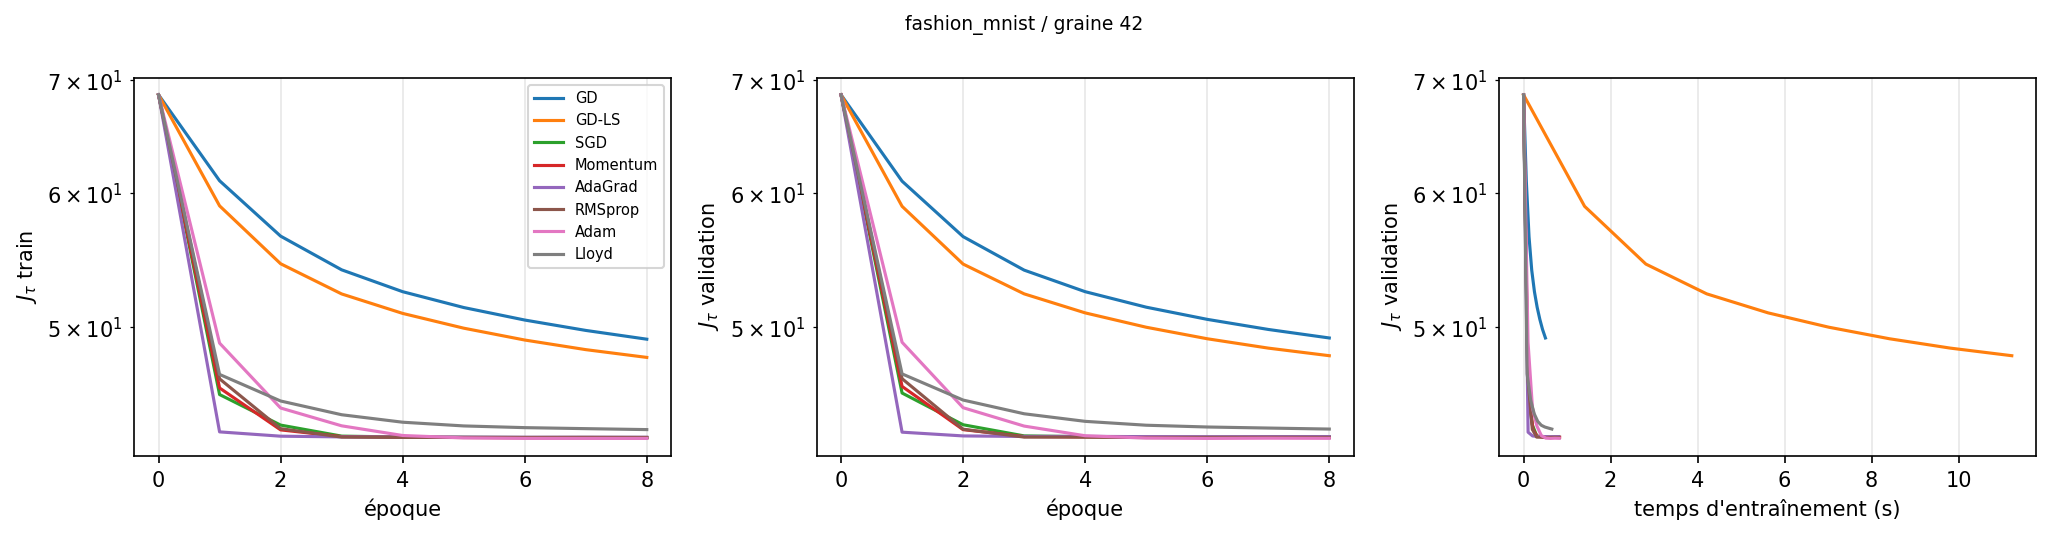

results/figs/clu_fashion_mnist_examples.png


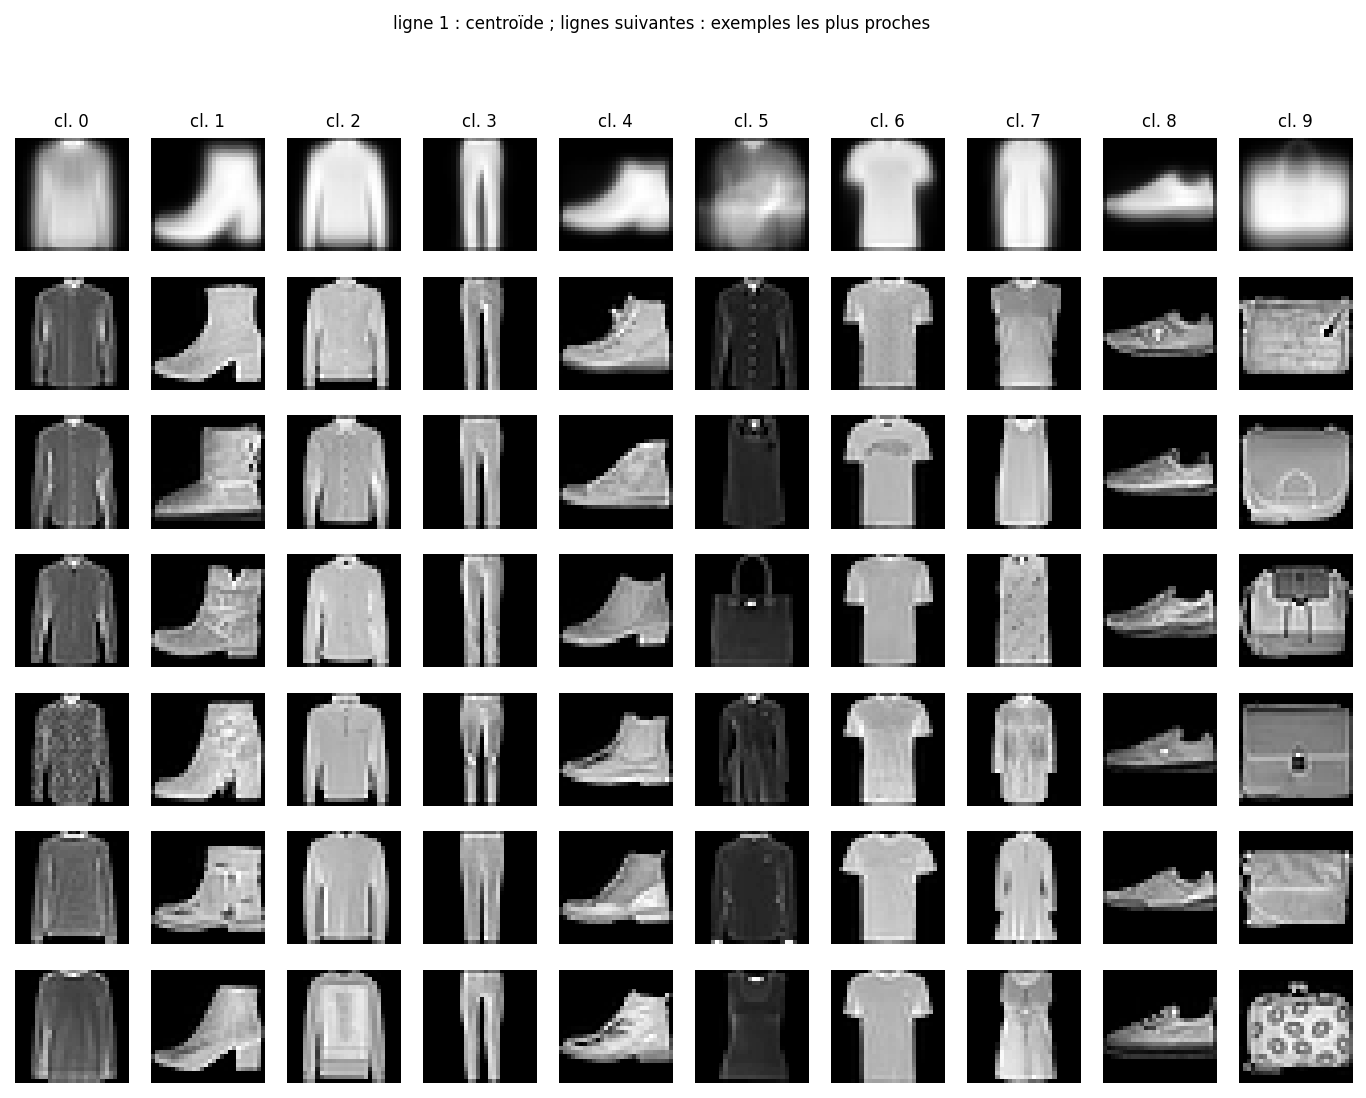

results/figs/clu_fashion_mnist_pca.png


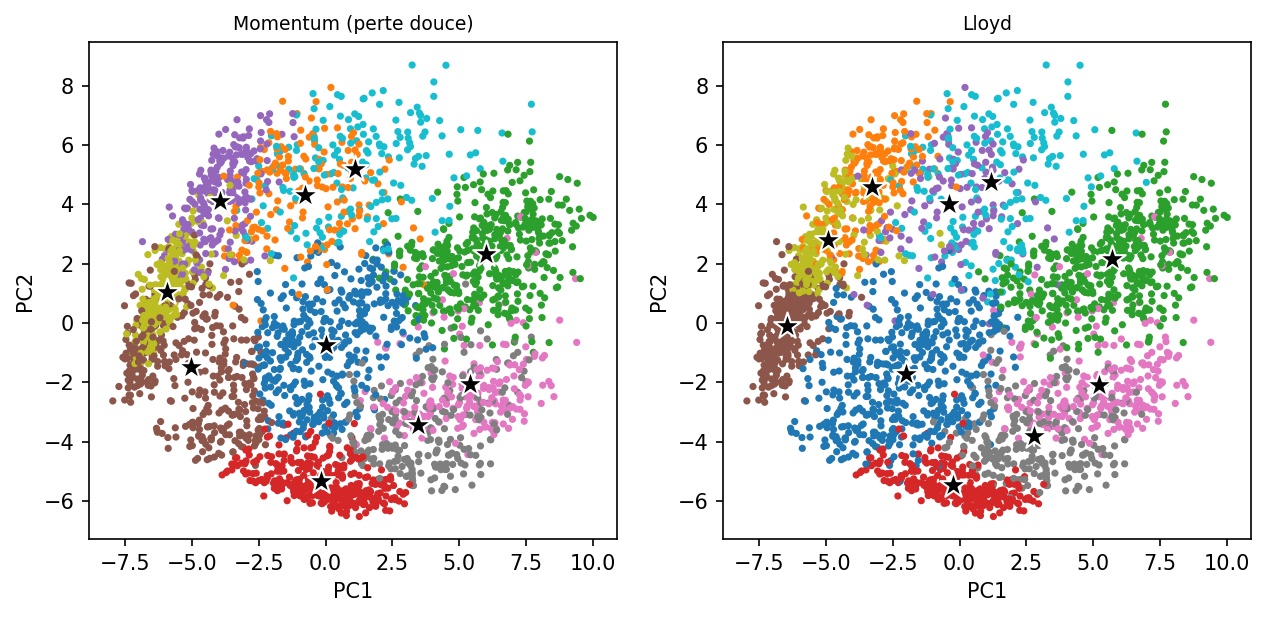

results/figs/clu_fashion_mnist_sizes.png


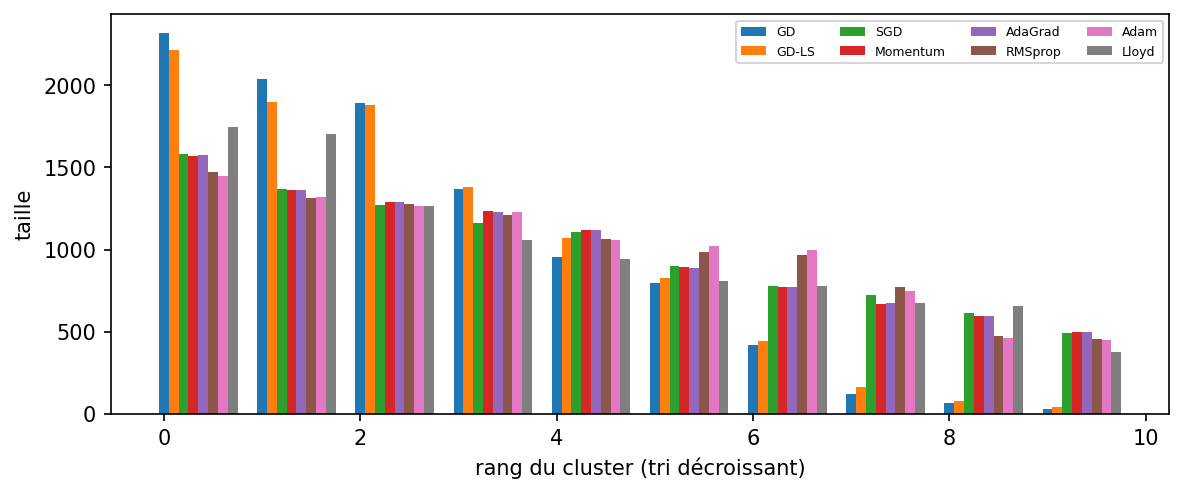

In [24]:
show("clu_fashion_mnist")